In [1]:
# ============================================================
#  JV Program – VLR México
#  Script 01: Extracción ETL + EDA completo
#  Ejecutar celda por celda en Jupyter Notebook
#  Requiere: pyodbc, pandas, numpy, matplotlib, seaborn
# ============================================================

In [2]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
 
# Estilo visual corporativo
plt.rcParams.update({
    "font.family": "Arial",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLOR_CORP = "#2E75B6"
PALETTE    = ["#1a3a5c","#2E75B6","#4A90C4","#5B9BD5","#78B4E0","#9ECAE8"]

def yyww_to_date(val):
    """
    Convierte 'WEEK 2550' → fecha del lunes de la semana ISO correspondiente.
    Ejemplos:
        'WEEK 2501' → 2025-01-06  (semana 1 del 2025)
        'WEEK 2552' → 2025-12-22  (semana 52 del 2025)
        'WEEK 2601' → 2025-12-29  (semana 1 del 2026, que cae en dic 2025)
    """
    try:
        num = str(val).replace("WEEK", "").strip().zfill(4)
        year = int("20" + num[:2])
        week = int(num[2:])
        return pd.Timestamp.fromisocalendar(year, week, 1)
    except:
        return pd.NaT

print("✅ Función yyww_to_date definida")
 
print("✅ Librerías cargadas correctamente")

✅ Función yyww_to_date definida
✅ Librerías cargadas correctamente


In [ ]:
# ── CELDA 2: Conexión a SQL Server Express ────────────────────
# FIX DE SEGURIDAD: el archivo obtiene acceso directo a la base de datos de VLR México. 
# motivo por el que no fueron agregados en este script los datos de conexión (usuario, contraseña, servidor, base de datos).
# se ha ejecutado y se cuenta con la informacion para poder ejecutar la app
#


import os

# Si usas un archivo .env, descomenta estas 2 líneas (requiere: pip install python-dotenv)
# from dotenv import load_dotenv
# load_dotenv()

SERVER   = os.environ.get("JV_DB_SERVER")
DATABASE = os.environ.get("JV_DB_DATABASE", "DB_MASTER_PLAN")
USERNAME = os.environ.get("JV_DB_USER")
PASSWORD = os.environ.get("JV_DB_PASSWORD")

if not all([SERVER, USERNAME, PASSWORD]):
    raise RuntimeError(
        "Faltan variables de entorno de conexión (JV_DB_SERVER, JV_DB_USER, "
        "JV_DB_PASSWORD). Configúralas antes de continuar — ver instrucciones "
        "en el comentario de esta celda. NUNCA escribas las credenciales "
        "directamente en el código."
    )

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"UID={USERNAME};"
    f"PWD={PASSWORD};"
)

conn = None
try:
    conn = pyodbc.connect(conn_str)
    print(f"✅ Conexión exitosa a {SERVER} / {DATABASE}")
except Exception as e:
    print(f"❌ Error de conexión: {e}")
    print("   Verifica SERVER, DATABASE, usuario/contraseña y que SQL Server esté activo.")


✅ Conexión exitosa a 192.168.118.52\SQLEXPRESS / DB_MASTER_PLAN


In [ ]:

# ── CELDA 3: Extracción de tablas principales ─────────────────
def leer(query, label=""):
    df = pd.read_sql(query, conn)
    print(f"   {label}: {len(df):,} filas, {df.shape[1]} columnas")
    return df
 
print("📥 Extrayendo tablas...")

 
# Master Plan — universo de órdenes
df_mp = leer("""
    SELECT WO, CUSTOMER, ITEM, DESCRIPTION_ITEM, BODY_PILLOW,
           FAMILY, QTY, PRODUCTION_WEEK, SCHEDULE_DATE, FABRIC,
           STATUS, TIME_PRESEW_Inhours, TIME_SEWING_inhours,
           Cutting_fabric_hours, CLASIFICACION, PRIORITY
    FROM tbMaster_plan
    WHERE STATUS <> 'CANCELLED'
    AND SCHEDULE_DATE > '12/31/2024'
    and BODY_PILLOW <> 'PILLOW/TICKING'
""", "tbMaster_plan")
 
# Corte
df_cut = leer("""
    SELECT c.WO,
           c.OPERATION_DATE  AS FECHA_FIN_CORTE,
           ca.OPERATION_DATE AS FECHA_INI_CORTE,
           ca.ID_NUMBER      AS OPERARIO_CORTE,
           ca.LINE_TABLE     AS LINEA_CORTE

    FROM tbCUT c
    LEFT JOIN tbCUTTING_ASSIGNMENT ca ON c.WO = ca.WO
    LEFT JOIN tbMaster_plan mp ON c.WO = mp.WO
    WHERE c.OPERATION_DATE > '12/31/2024'
    AND mp.WO IS NOT NULL
    AND (mp.BODY_PILLOW IS NULL OR mp.BODY_PILLOW <> 'PILLOW/TICKING')
""", "tbCUT + ASSIGNMENT")
 
# Preparación
df_prep = leer("""
    SELECT kp.WO,
           kp.OPERATION_DATE AS FECHA_INI_PREP,
           kp.ID_NUMBER      AS OPERARIO_PREP,
           kp.LINE_TABLE     AS LINEA_PREP

    FROM tbKANBAN_PREP kp
    LEFT JOIN tbMaster_plan mp ON kp.WO = mp.WO
    WHERE OPERATION_DATE > '12/31/2024'
    AND mp.WO IS NOT NULL
    AND (mp.BODY_PILLOW IS NULL OR mp.BODY_PILLOW <> 'PILLOW/TICKING')
""", "tbKANBAN_PREP")
 
# Costura
df_sew = leer("""
    SELECT s.WO,
           s.OPERATION_DATE  AS FECHA_FIN_COSTURA,
           sa.OPERATION_DATE AS FECHA_INI_COSTURA,
           sa.ID_NUMBER      AS OPERARIO_COSTURA,
           sa.LINE_TABLE     AS LINEA_COSTURA

    FROM tbSEWING s
    LEFT JOIN tbSEWING_ASSIGNMENT sa ON s.WO = sa.WO
    LEFT JOIN tbMaster_plan mp ON sa.WO = mp.WO
    WHERE s.OPERATION_DATE > '12/31/2024'
    AND mp.WO IS NOT NULL
    AND (mp.BODY_PILLOW IS NULL OR mp.BODY_PILLOW <> 'PILLOW/TICKING')
""", "tbSEWING + ASSIGNMENT")
 
# QC — Control de Calidad (usando la vista consolidada)
df_qc = leer("""
    SELECT qc.WO, qc.id_qc,
           qc.OPERATION_DATE AS FECHA_QC,
           qc.OPERATION      AS AREA_QC,
           qc.APPROVED,
           qc.QTY_AUDIT,
           qc.QTY_RECHAZADO,
           qc.COD_DEFECT,
           qc.COD_PART,
           qc.COD_UNI,
           qc.ID_NUMBER  AS OPERARIO_QC1,
           qc.ID_NUMBER2 AS OPERARIO_QC2,
           qc.LINE_TABLE,
           qc.COMMENTS

    FROM tbQC qc
    LEFT JOIN tbMaster_plan mp ON qc.WO = mp.WO
    WHERE OPERATION_DATE > '12/31/2024'
    AND mp.WO IS NOT NULL
    AND (mp.BODY_PILLOW IS NULL OR mp.BODY_PILLOW <> 'PILLOW/TICKING')
""", "tbQC")
 
# Embarque
df_ship = leer("""
    SELECT ws.WO,
           s.OPERATION_DATE AS FECHA_EMBARQUE,
           s.REF_CONTAINER
    FROM tbWOSHIPPED ws
    JOIN tbSHIPPED s ON ws.id_shipped = s.id_shipped
    LEFT JOIN tbMaster_plan mp ON s.WO = mp.WO
    WHERE s.OPERATION_DATE > '12/31/2024'
    AND mp.WO IS NOT NULL
    AND (mp.BODY_PILLOW IS NULL OR mp.BODY_PILLOW <> 'PILLOW/TICKING')
""", "tbSHIPPED")
 
# Catálogos
df_defectos    = leer("SELECT Id_defect, COD_DEFECT, DESCRIPTION FROM tbDefectos",       "tbDefectos")
df_partes      = leer("SELECT Id_part, COD_PART, PART_DEFECT FROM tbParteMueble",        "tbParteMueble")
df_unificacion = leer("SELECT Id_uni, COD_UNI, UNIFICATION FROM tbUNIFICACION",          "tbUNIFICACION")
df_workforce   = leer("SELECT ID_NUMBER, FULLNAME, SUB_AREA, WORK_TEAM FROM tbWORKFORCE","tbWORKFORCE")
 
print("✅ Extracción completada")

📥 Extrayendo tablas...
   tbMaster_plan: 44,133 filas, 16 columnas
   tbCUT + ASSIGNMENT: 43,735 filas, 5 columnas
   tbKANBAN_PREP: 43,982 filas, 4 columnas
   tbSEWING + ASSIGNMENT: 42,775 filas, 5 columnas
   tbQC: 44,057 filas, 14 columnas
   tbSHIPPED: 67,739 filas, 3 columnas
   tbDefectos: 52 filas, 3 columnas
   tbParteMueble: 18 filas, 3 columnas
   tbUNIFICACION: 11 filas, 3 columnas
   tbWORKFORCE: 206 filas, 4 columnas
✅ Extracción completada


In [5]:
# ── CELDA 4: Conversión de fechas ─────────────────────────────
# SQL Server puede devolver fechas como string en algunas tablas
for df, cols in [
    (df_cut,  ["FECHA_FIN_CORTE",  "FECHA_INI_CORTE"]),
    (df_prep, ["FECHA_INI_PREP"]),
    (df_sew,  ["FECHA_FIN_COSTURA","FECHA_INI_COSTURA"]),
    (df_qc,   ["FECHA_QC"]),
    (df_ship, ["FECHA_EMBARQUE"]),
    (df_mp,   ["SCHEDULE_DATE"]),
]:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
 
print("✅ Fechas convertidas a datetime")

✅ Fechas convertidas a datetime


In [6]:
# ── CELDA 5: Construcción del dataset WO-nivel ────────────────
# JOIN progresivo: Master Plan es la base (LEFT JOIN todo)
dw = df_mp.copy()
dw = dw.merge(df_cut,  on="WO", how="left")
dw = dw.merge(df_prep, on="WO", how="left")
dw = dw.merge(df_sew,  on="WO", how="left")
dw = dw.merge(df_ship, on="WO", how="left")
 
# QC: agregar por WO (tomar el resultado más desfavorable)
qc_agg = df_qc.groupby("WO").agg(
    APPROVED      = ("APPROVED",      "min"),   # 0 si alguna inspección fue rechazada
    QTY_AUDIT_TOT = ("QTY_AUDIT",     "sum"),
    QTY_RECH_TOT  = ("QTY_RECHAZADO", "sum"),
    N_INSPECCIONES= ("id_qc",         "count"),
).reset_index()
 
dw = dw.merge(qc_agg, on="WO", how="left")
 
print(f"✅ Dataset WO-nivel: {dw.shape[0]:,} filas × {dw.shape[1]} columnas")
print(f"   WO con QC: {qc_agg.shape[0]:,}  |  WO sin QC aún: {dw['APPROVED'].isna().sum()}")

✅ Dataset WO-nivel: 44,485 filas × 33 columnas
   WO con QC: 44,057  |  WO sin QC aún: 905


In [7]:
# ── CELDA 6: Variables derivadas ──────────────────────────────
# ES_RECHAZADA: 1 si fue rechazada (APPROVED=0), 0 si aprobada
dw["ES_RECHAZADA"] = (dw["APPROVED"] == 0).astype(int)
 
# Tiempos de ciclo en días
dw["TC_CORTE_H"]   = (dw["FECHA_FIN_CORTE"]   - dw["FECHA_INI_CORTE"]).dt.total_seconds() / 3600
dw["TC_PREP_H"]    = (dw["FECHA_INI_COSTURA"]  - dw["FECHA_INI_PREP"]).dt.total_seconds() / 3600
dw["TC_COSTURA_H"] = (dw["FECHA_FIN_COSTURA"]  - dw["FECHA_INI_COSTURA"]).dt.total_seconds() / 3600
dw["TC_TOTAL_D"]   = (dw["FECHA_EMBARQUE"]     - dw["FECHA_INI_CORTE"]).dt.total_seconds() / 86400
 
# Tasa de rechazo
dw["TASA_RECHAZO"] = (dw["QTY_RECH_TOT"] / dw["QTY_AUDIT_TOT"].replace(0, np.nan)) * 100
 
# Eficiencias (tiempo real / tiempo estándar * QTY)
dw["EFIC_CORTE"]   = dw["TC_CORTE_H"]   / (dw["Cutting_fabric_hours"]  * dw["QTY"] + 1e-9) * 100
dw["EFIC_PREP"]    = dw["TC_PREP_H"]    / (dw["TIME_PRESEW_Inhours"]   * dw["QTY"] + 1e-9) * 100
dw["EFIC_COSTURA"] = dw["TC_COSTURA_H"] / (dw["TIME_SEWING_inhours"]   * dw["QTY"] + 1e-9) * 100
 
# Semana numérica (YYWW → entero para ordenar cronológicamente)
dw["SEMANA_NUM"] = (dw["PRODUCTION_WEEK"]
                     .astype(str)
                     .str.replace("WEEK", "", regex=False)
                     .str.strip()
                     .pipe(pd.to_numeric, errors="coerce"))

dw["FECHA_SEMANA"] = dw["PRODUCTION_WEEK"].apply(yyww_to_date)

carga = (dw.groupby("SEMANA_NUM")["WO"]
           .count()
           .reset_index()
           .rename(columns={"WO": "CARGA_SEMANA"}))
dw = dw.merge(carga, on="SEMANA_NUM", how="left")

print(f"✅ SEMANA_NUM:   {dw['SEMANA_NUM'].notna().sum()} valores")
print(f"✅ FECHA_SEMANA: {dw['FECHA_SEMANA'].notna().sum()} valores")
print(f"✅ CARGA_SEMANA: {dw['CARGA_SEMANA'].notna().sum()} valores")
 
# Desvío de planificación
dw["DESVIO_PLAN_D"] = (dw["FECHA_EMBARQUE"] - dw["SCHEDULE_DATE"]).dt.days
dw["CUMPLE_FECHA"]  = (dw["DESVIO_PLAN_D"] <= 0).astype(int)
 
# Día de semana de inicio
dw["DIA_INICIO"] = dw["FECHA_INI_CORTE"].dt.dayofweek  # 0=lunes
 
print("✅ Variables derivadas calculadas")
print(dw[["WO","TC_TOTAL_D","TASA_RECHAZO","ES_RECHAZADA","EFIC_COSTURA"]].head(5).to_string())

✅ SEMANA_NUM:   44485 valores
✅ FECHA_SEMANA: 44455 valores
✅ CARGA_SEMANA: 44485 valores
✅ Variables derivadas calculadas
        WO  TC_TOTAL_D  TASA_RECHAZO  ES_RECHAZADA  EFIC_COSTURA
0  2529934    5.067591           0.0             1    446.000356
1  2529937    4.271563           0.0             1    438.474280
2  2529940    5.062670           0.0             1    287.535847
3  2529943    5.215458           0.0             1   2249.679078
4  2529946    5.345429           0.0             1    792.568334


In [8]:
# ── CELDA 7: Limpieza de outliers evidentes ───────────────────
# Tiempos negativos = error de captura
for col in ["TC_CORTE_H","TC_PREP_H","TC_COSTURA_H","TC_TOTAL_D"]:
    n = (dw[col] < 0).sum()
    dw.loc[dw[col] < 0, col] = np.nan
    if n: print(f"   ⚠️  {n} valores negativos en {col} → NaN")
 
# Eficiencias fuera de rango razonable (>500% = error)
for col in ["EFIC_CORTE","EFIC_PREP","EFIC_COSTURA"]:
    n = (dw[col] > 500).sum()
    dw.loc[dw[col] > 500, col] = np.nan
    if n: print(f"   ⚠️  {n} valores >500% en {col} → NaN")
 
print("✅ Limpieza básica completada")
 
 
# ── CELDA 8: Exportar datasets ────────────────────────────────
dw.to_parquet("dataset_WO_nivel.parquet", index=False)
dw.to_csv("dataset_WO_nivel.csv", index=False)
 
# Dataset QC enriquecido con catálogos
df_qc_enriq = (df_qc
    .merge(df_defectos,    left_on="COD_DEFECT", right_on="COD_DEFECT", how="left")
    .merge(df_partes,      left_on="COD_PART",   right_on="COD_PART",   how="left")
    .merge(df_unificacion, left_on="COD_UNI",    right_on="COD_UNI",    how="left")
    .merge(df_workforce,   left_on="OPERARIO_QC1", right_on="ID_NUMBER", how="left")
    .merge(df_mp[["WO","PRODUCTION_WEEK","ITEM","CUSTOMER","FAMILY"]], on="WO", how="left")
)
df_qc_enriq["ES_RECHAZADA"] = (df_qc_enriq["APPROVED"] == 0).astype(int)
df_qc_enriq.to_parquet("dataset_QC_eventos.parquet", index=False)
 
print(f"✅ Datasets guardados:")
print(f"   dataset_WO_nivel.parquet    ({len(dw):,} WO)")
print(f"   dataset_QC_eventos.parquet  ({len(df_qc_enriq):,} eventos de QC)")

   ⚠️  5 valores negativos en TC_CORTE_H → NaN
   ⚠️  26546 valores negativos en TC_PREP_H → NaN
   ⚠️  16 valores negativos en TC_COSTURA_H → NaN
   ⚠️  22861 valores >500% en EFIC_CORTE → NaN
   ⚠️  12935 valores >500% en EFIC_PREP → NaN
   ⚠️  14777 valores >500% en EFIC_COSTURA → NaN
✅ Limpieza básica completada
✅ Datasets guardados:
   dataset_WO_nivel.parquet    (44,485 WO)
   dataset_QC_eventos.parquet  (44,057 eventos de QC)


In [9]:
# ══════════════════════════════════════════════════════════════
#  SCRIPT 02: EDA — Análisis Exploratorio de Datos
# ══════════════════════════════════════════════════════════════

In [10]:
# ── CELDA 9: Cargar dataset (si empiezas en una sesión nueva) ──
# dw = pd.read_parquet("dataset_WO_nivel.parquet")
# df_qc_enriq = pd.read_parquet("dataset_QC_eventos.parquet")

In [11]:
# ── CELDA 10: TABLA 9 — Resumen estadístico ───────────────────
# Estos son los valores que van en los [X] del documento Word
 
vars_stats = {
    "Tiempo Ciclo Total (días)": "TC_TOTAL_D",
    "Tiempo Ciclo Corte (h)":    "TC_CORTE_H",
    "Tiempo Ciclo Costura (h)":  "TC_COSTURA_H",
    "Cantidad Defectos":         "QTY_RECH_TOT",
    "Tasa Rechazo (%)":          "TASA_RECHAZO",
    "Eficiencia Costura (%)":    "EFIC_COSTURA",
}
 
print("\n" + "="*80)
print("TABLA 9 — Resumen estadístico (copiar al documento Word)")
print("="*80)
 
resultados = []
for label, col in vars_stats.items():
    if col in dw.columns:
        serie = dw[col].dropna()
        resultados.append({
            "Variable":    label,
            "N":           len(serie),
            "Media":       round(serie.mean(), 2),
            "Mediana":     round(serie.median(), 2),
            "Desv. Est.":  round(serie.std(), 2),
            "Mínimo":      round(serie.min(), 2),
            "Máximo":      round(serie.max(), 2),
            "Asimetría":   round(serie.skew(), 2),
        })
 
tabla9 = pd.DataFrame(resultados).set_index("Variable")
print(tabla9.to_string())
print("\n✅ Copia estos valores en la Tabla 9 del documento Word")
 


TABLA 9 — Resumen estadístico (copiar al documento Word)
                               N   Media  Mediana  Desv. Est.    Mínimo  Máximo  Asimetría
Variable                                                                                  
Tiempo Ciclo Total (días)  43425    4.18     4.36        2.58      0.01   40.05       1.85
Tiempo Ciclo Corte (h)     43763   17.39     5.13       27.56      0.00  506.40       3.26
Tiempo Ciclo Costura (h)   42761    6.43     2.40       17.20      0.00  435.53       7.33
Cantidad Defectos          43580    0.02     0.00        0.18      0.00   12.00      16.02
Tasa Rechazo (%)           41371    1.96     0.00       13.88      0.00  300.00       7.31
Eficiencia Costura (%)     27422  158.96   152.31      842.42 -63472.03  499.99     -61.85

✅ Copia estos valores en la Tabla 9 del documento Word


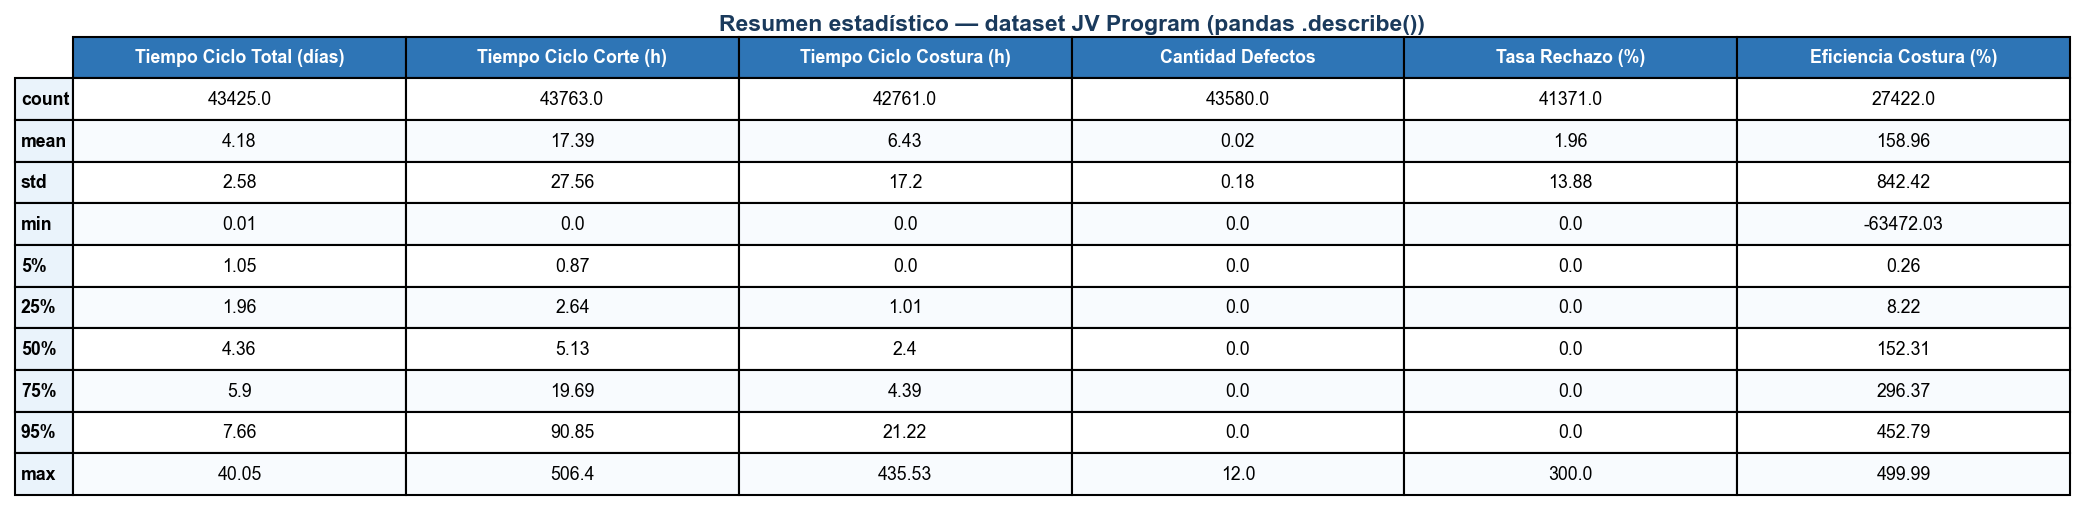

✅ Figura 4 guardada: figura04_describe.png


In [12]:
# ── CELDA 11: FIGURA 4 — df.describe() exportado como imagen ──
desc = dw[list(vars_stats.values())].describe(percentiles=[.05,.25,.5,.75,.95])
desc.columns = list(vars_stats.keys())
desc = desc.round(2)
 
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis("off")
 
tbl = ax.table(
    cellText  = desc.values,
    colLabels = desc.columns,
    rowLabels = desc.index,
    cellLoc   = "center",
    loc       = "center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.6)
 
# Colorear encabezados
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2E75B6")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#EAF3FB")
        cell.set_text_props(fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F8FBFE")
 
ax.set_title("Resumen estadístico — dataset JV Program (pandas .describe())",
             pad=12, fontsize=11, color="#1a3a5c", fontweight="bold")
plt.tight_layout()
plt.savefig("figura04_describe.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("✅ Figura 4 guardada: figura04_describe.png")

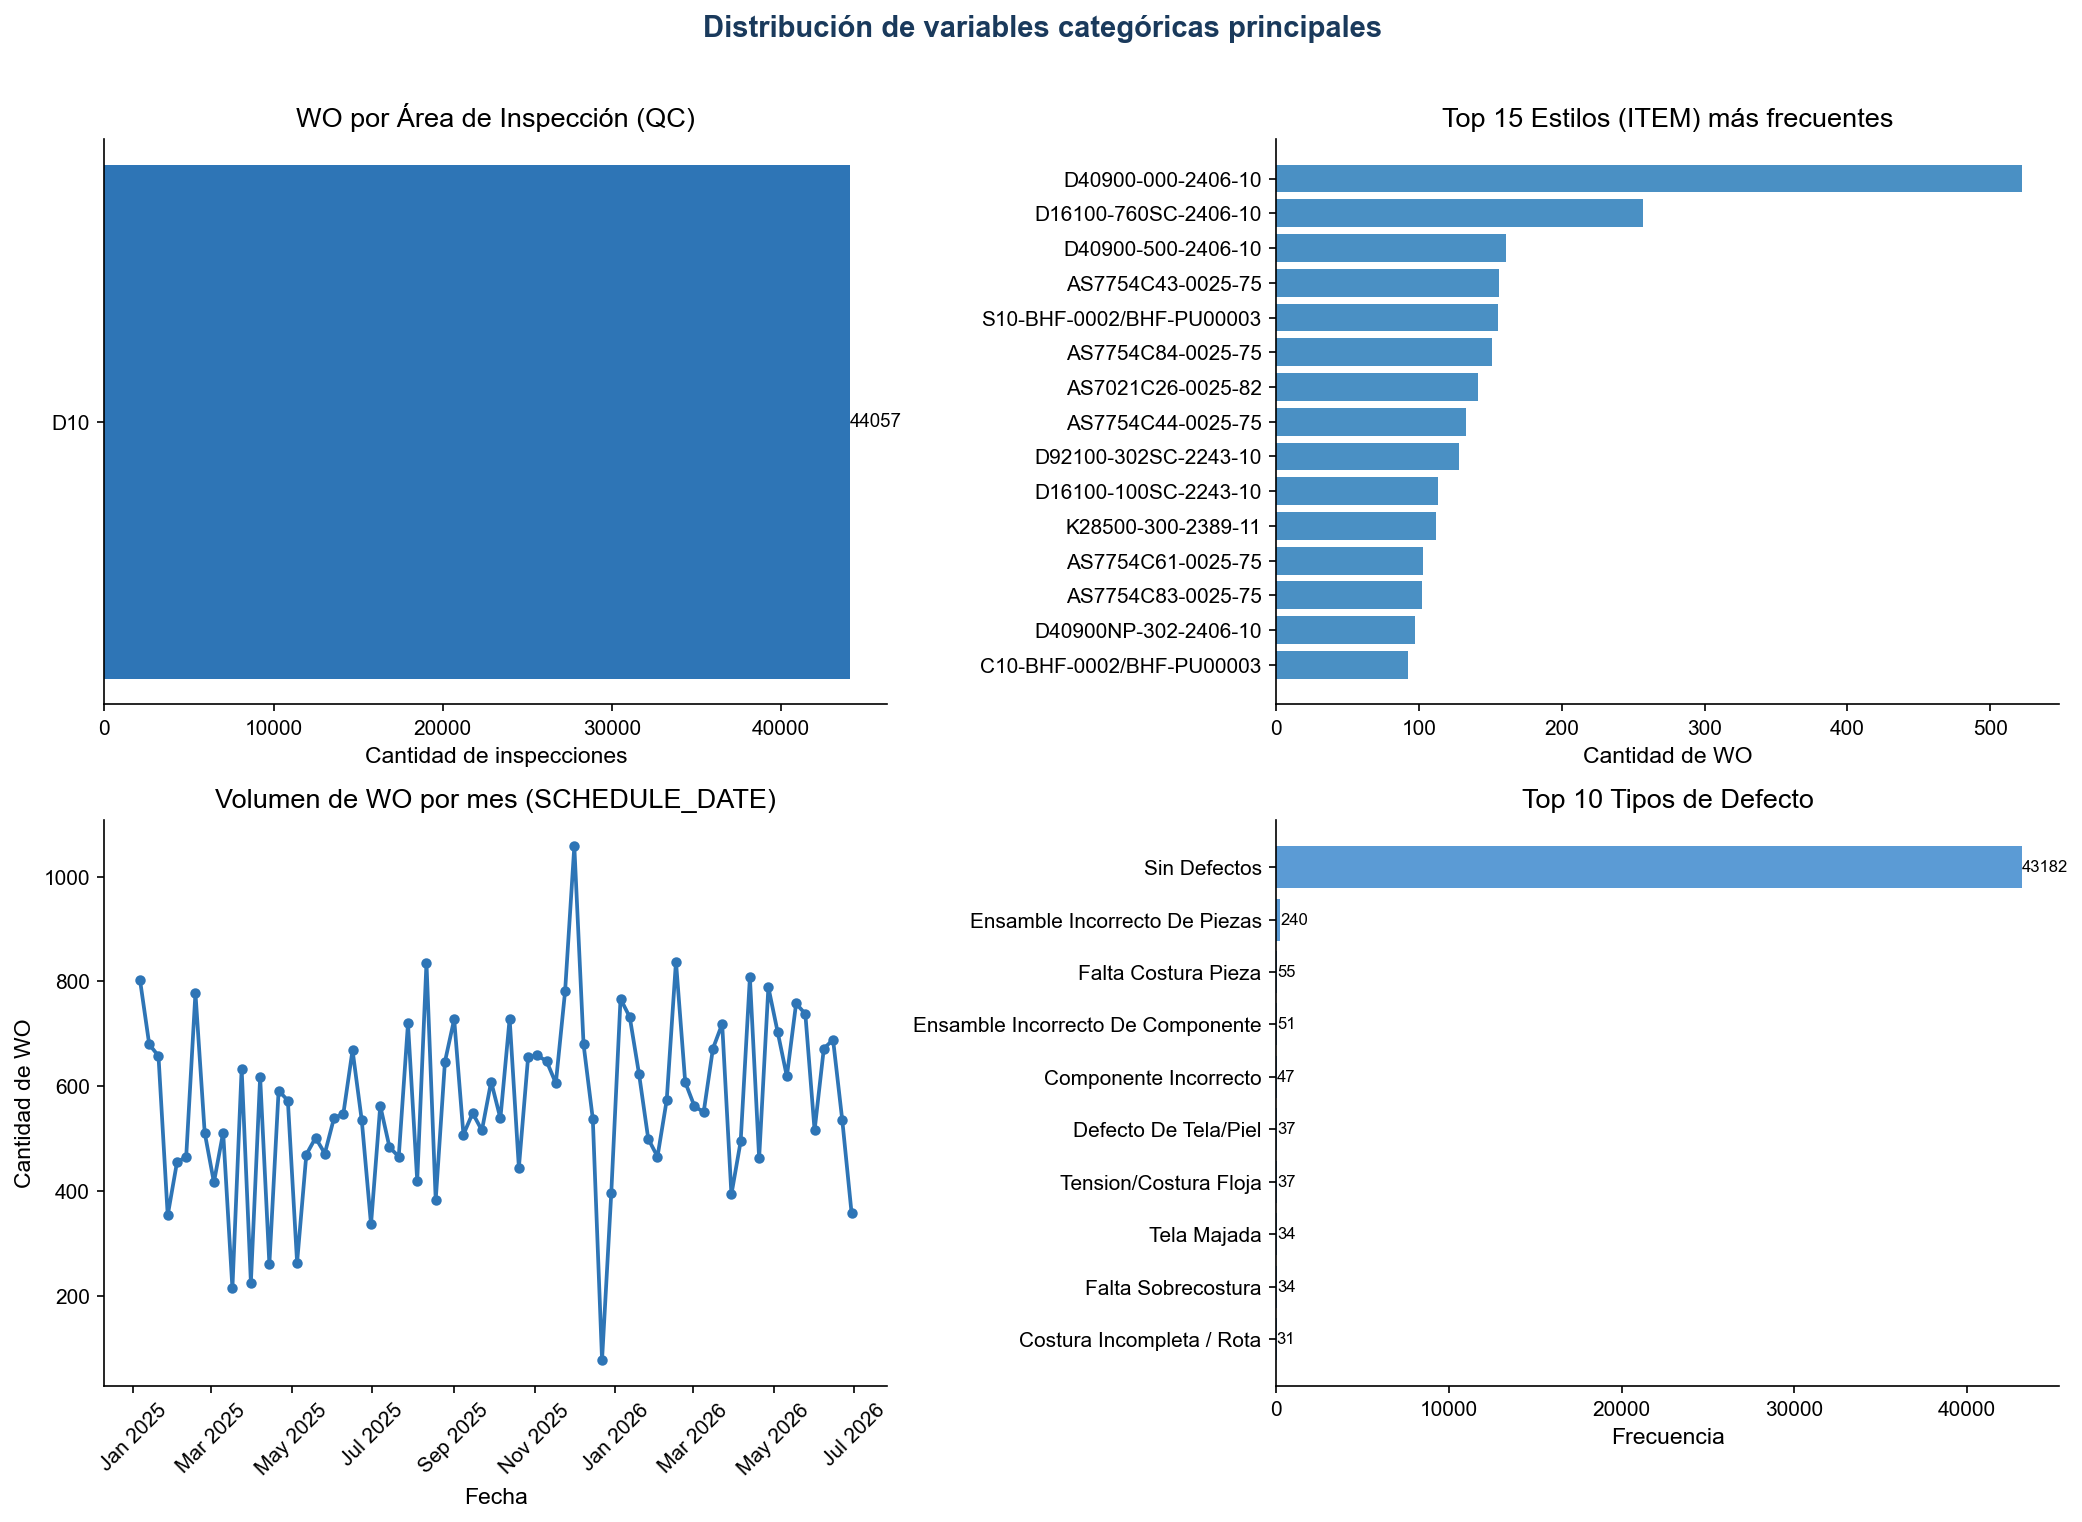

✅ Figura 5 guardada: figura05_categoricas.png


In [13]:
# ── CELDA 12: FIGURA 5 — Distribución variables categóricas ───
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribución de variables categóricas principales", fontsize=14,
             fontweight="bold", color="#1a3a5c", y=1.01)
 
# 1. WO por área QC
area_counts = df_qc_enriq["AREA_QC"].value_counts()
axes[0,0].barh(area_counts.index, area_counts.values, color=COLOR_CORP)
axes[0,0].set_title("WO por Área de Inspección (QC)")
axes[0,0].set_xlabel("Cantidad de inspecciones")
for i, v in enumerate(area_counts.values):
    axes[0,0].text(v + 0.5, i, str(v), va="center", fontsize=9)
 
# 2. Top 15 ITEM más frecuentes
item_counts = dw["ITEM"].value_counts().head(15)
axes[0,1].barh(item_counts.index[::-1], item_counts.values[::-1],
               color=PALETTE[2])
axes[0,1].set_title("Top 15 Estilos (ITEM) más frecuentes")
axes[0,1].set_xlabel("Cantidad de WO")
 
# 3. WO por semana — conversión YYWW a fecha real
dw["MES_SCHEDULE"] = dw["SCHEDULE_DATE"].dt.to_period("W").dt.start_time

semana_cnt2 = (dw.groupby("MES_SCHEDULE")["WO"]
                .count()
                .reset_index()
                .sort_values("MES_SCHEDULE"))

axes[1,0].plot(semana_cnt2["MES_SCHEDULE"], semana_cnt2["WO"],
               color=COLOR_CORP, linewidth=1.8, marker="o", markersize=4)
axes[1,0].set_title("Volumen de WO por mes (SCHEDULE_DATE)")
axes[1,0].set_xlabel("Fecha")
axes[1,0].set_ylabel("Cantidad de WO")
axes[1,0].xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%b %Y"))
axes[1,0].tick_params(axis="x", rotation=45)

# 4. Tipos de defecto top 10
if "DESCRIPTION" in df_qc_enriq.columns:
    defecto_cnt = df_qc_enriq["DESCRIPTION"].value_counts().head(10)
    axes[1,1].barh(defecto_cnt.index[::-1], defecto_cnt.values[::-1],
                   color=PALETTE[3])
    axes[1,1].set_title("Top 10 Tipos de Defecto")
    axes[1,1].set_xlabel("Frecuencia")
    for i, v in enumerate(defecto_cnt.values[::-1]):
        axes[1,1].text(v + 0.3, i, str(v), va="center", fontsize=8)
 
plt.tight_layout()
plt.savefig("figura05_categoricas.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("✅ Figura 5 guardada: figura05_categoricas.png")

Semanas a graficar: 77
Rango: 2025-01-06 → 2026-07-06


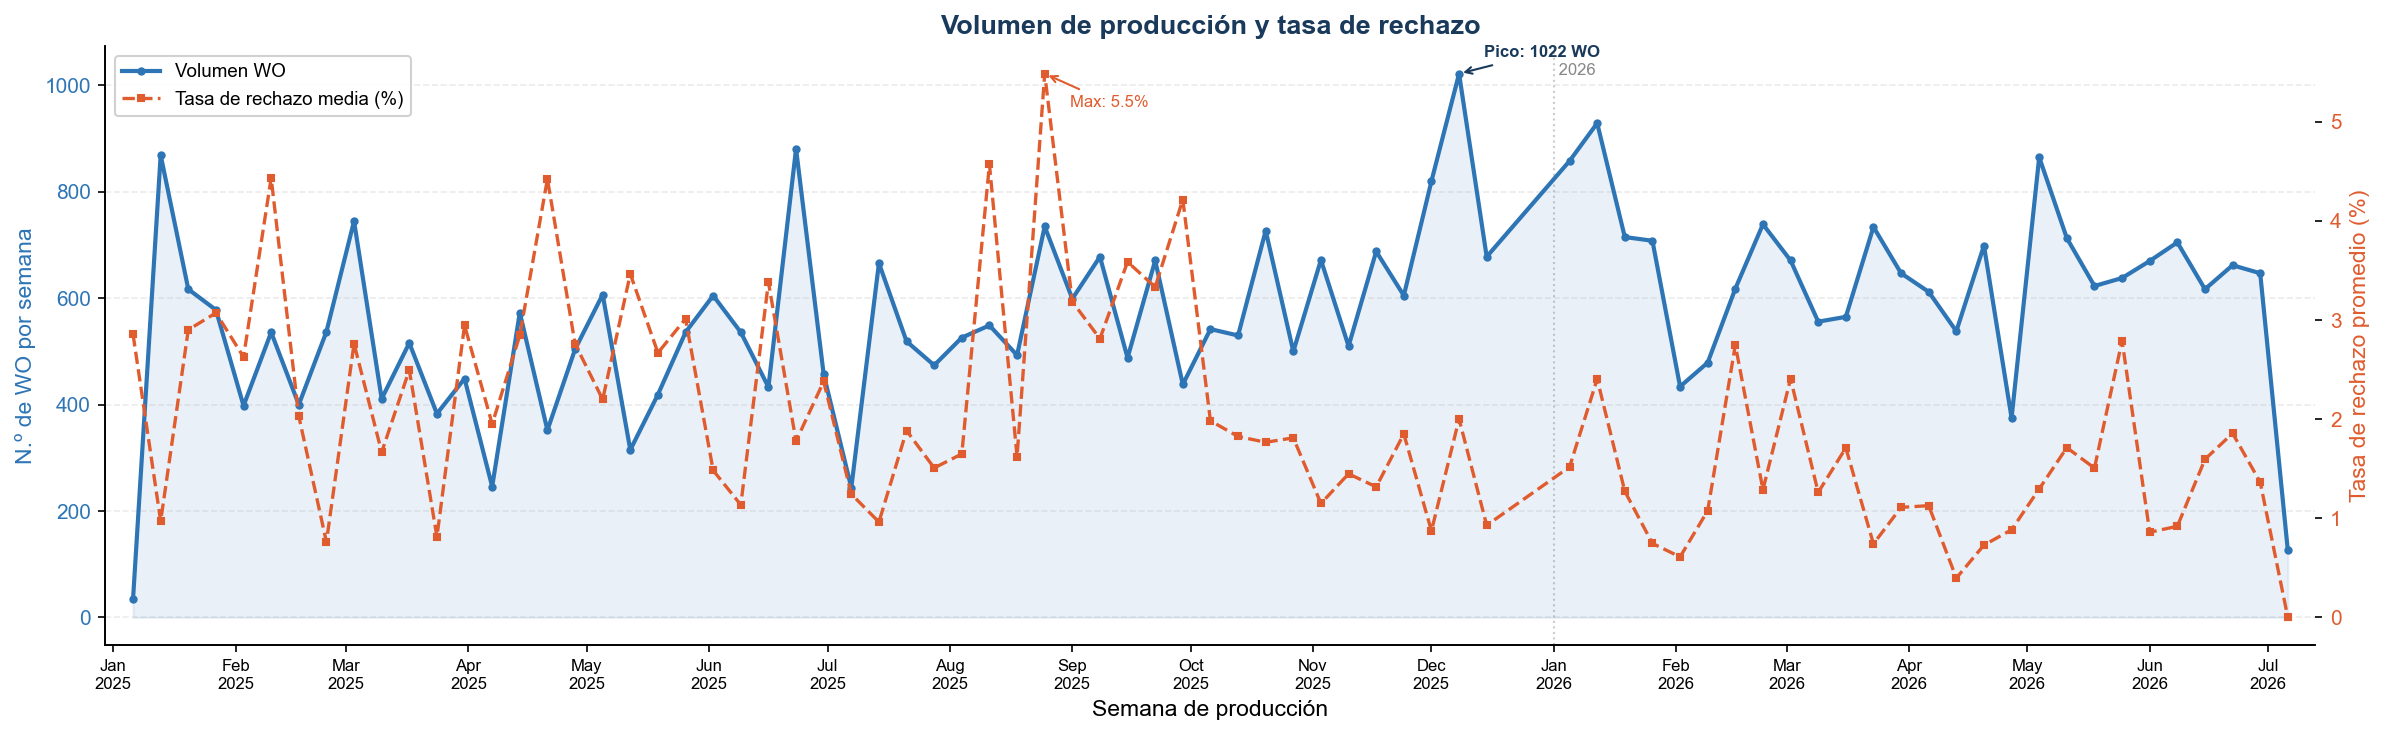

✅ Figura 6 guardada


In [14]:
# ── CELDA 13: FIGURA 6 — Serie temporal (eje X con fechas reales) ───────────
import matplotlib.dates as mdates

semana_stats = (dw.groupby("FECHA_SEMANA")
                  .agg(
                      N_WO          = ("WO",           "count"),
                      TASA_RECH_MED = ("TASA_RECHAZO", "mean"),
                  )
                  .reset_index()
                  .sort_values("FECHA_SEMANA")
                  .dropna(subset=["FECHA_SEMANA"]))

# Rellenar NaN de tasa para que la línea no se corte
semana_stats["TASA_RECH_MED"] = semana_stats["TASA_RECH_MED"].fillna(0)

print(f"Semanas a graficar: {len(semana_stats)}")
print(f"Rango: {semana_stats['FECHA_SEMANA'].min().date()} "
      f"→ {semana_stats['FECHA_SEMANA'].max().date()}")

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

# ── Línea volumen WO ─────────────────────────────────────────────────────────
ax1.plot(semana_stats["FECHA_SEMANA"], semana_stats["N_WO"],
         color=COLOR_CORP, linewidth=2, marker="o", markersize=3,
         label="Volumen WO")
ax1.fill_between(semana_stats["FECHA_SEMANA"], semana_stats["N_WO"],
                 alpha=0.10, color=COLOR_CORP)
ax1.set_ylabel("N.º de WO por semana", color=COLOR_CORP)
ax1.tick_params(axis="y", labelcolor=COLOR_CORP)

# ── Línea tasa de rechazo ────────────────────────────────────────────────────
ax2.plot(semana_stats["FECHA_SEMANA"], semana_stats["TASA_RECH_MED"],
         color="#E05C2E", linewidth=1.6, linestyle="--",
         marker="s", markersize=2.5, label="Tasa de rechazo media (%)")
ax2.set_ylabel("Tasa de rechazo promedio (%)", color="#E05C2E")
ax2.tick_params(axis="y", labelcolor="#E05C2E")

# ── Eje X: una marca por mes, etiqueta "Ene\n2025" ──────────────────────────
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax1.tick_params(axis="x", rotation=0, labelsize=8)

# ── Líneas verticales de cambio de año ──────────────────────────────────────
years = semana_stats["FECHA_SEMANA"].dt.year.unique()
for yr in years:
    inicio_año = pd.Timestamp(f"{yr}-01-01")
    if semana_stats["FECHA_SEMANA"].min() < inicio_año < semana_stats["FECHA_SEMANA"].max():
        ax1.axvline(inicio_año, color="#cccccc", linewidth=1,
                    linestyle=":", zorder=0)
        ax1.text(inicio_año, ax1.get_ylim()[1] * 0.95,
                 f" {yr}", fontsize=8, color="#888888")

# ── Anotaciones de picos ─────────────────────────────────────────────────────
idx_max_wo = semana_stats["N_WO"].idxmax()
ax1.annotate(
    f"Pico: {semana_stats.loc[idx_max_wo,'N_WO']} WO",
    xy=(semana_stats.loc[idx_max_wo,"FECHA_SEMANA"],
        semana_stats.loc[idx_max_wo,"N_WO"]),
    xytext=(12, 8), textcoords="offset points",
    fontsize=8, color="#1a3a5c", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#1a3a5c", lw=1)
)

idx_max_r = semana_stats["TASA_RECH_MED"].idxmax()
ax2.annotate(
    f"Max: {semana_stats.loc[idx_max_r,'TASA_RECH_MED']:.1f}%",
    xy=(semana_stats.loc[idx_max_r,"FECHA_SEMANA"],
        semana_stats.loc[idx_max_r,"TASA_RECH_MED"]),
    xytext=(12, -16), textcoords="offset points",
    fontsize=8, color="#E05C2E",
    arrowprops=dict(arrowstyle="->", color="#E05C2E", lw=1)
)

# ── Formato final ────────────────────────────────────────────────────────────
ax1.set_title("Volumen de producción y tasa de rechazo",
              fontsize=13, fontweight="bold", color="#1a3a5c")
ax1.set_xlabel("Semana de producción")
ax1.grid(axis="y", alpha=0.25, linestyle="--")
ax1.set_xlim(semana_stats["FECHA_SEMANA"].min() - pd.Timedelta(days=7),
             semana_stats["FECHA_SEMANA"].max() + pd.Timedelta(days=7))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("figura06_serie_temporal.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figura 6 guardada")

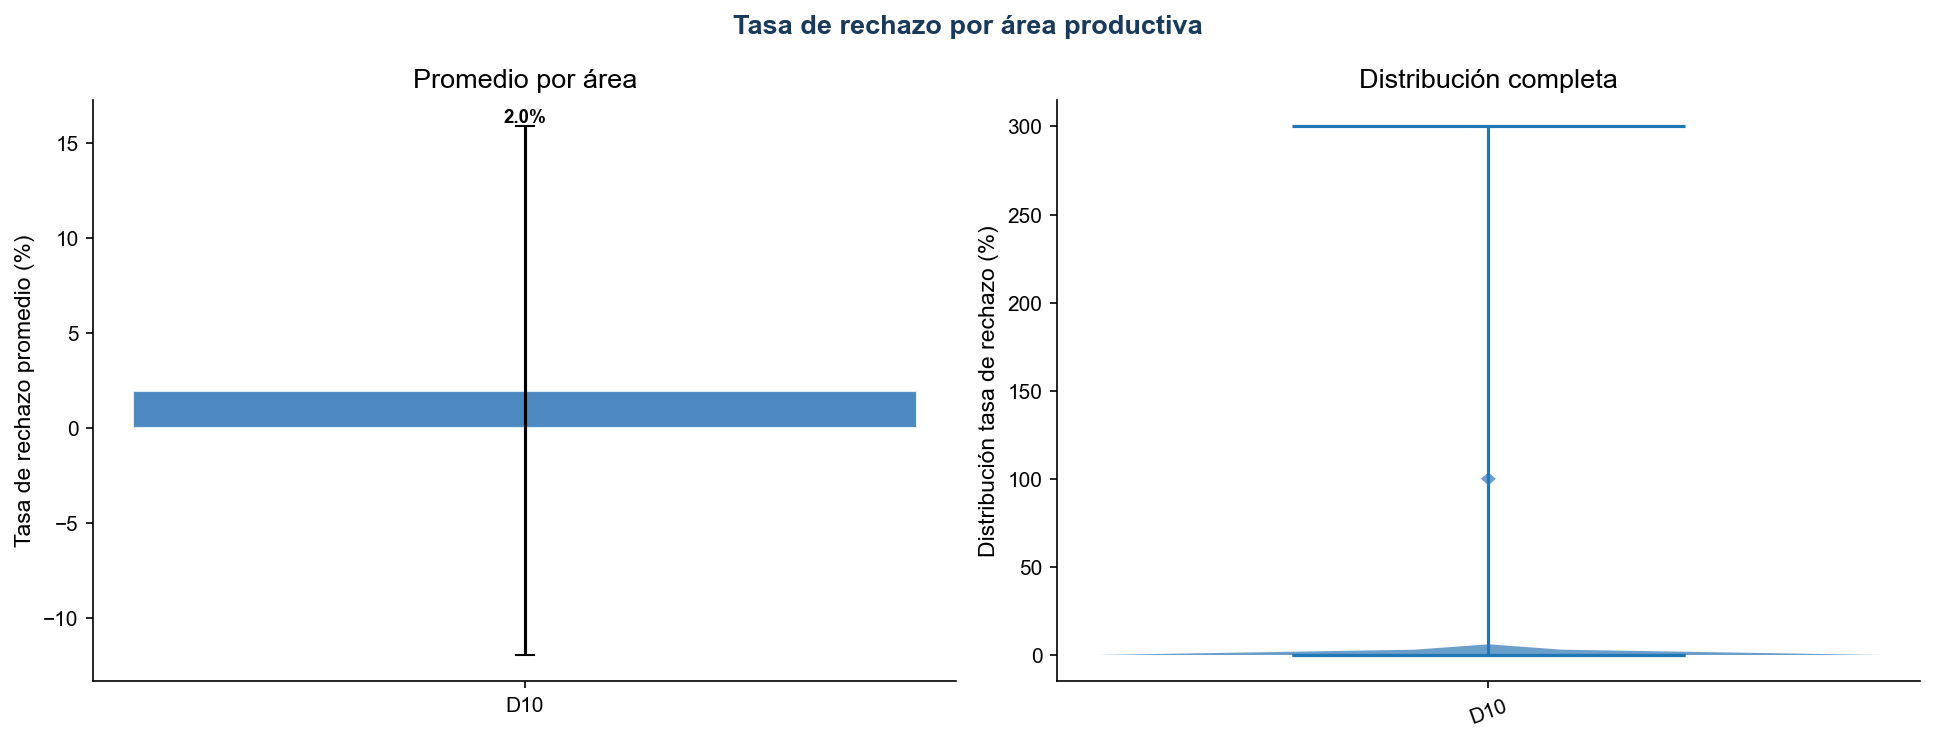

✅ Figura 7 guardada


In [15]:
# ── CELDA 14: FIGURA 7 — Tasa rechazo por área ────────────────
# FIX: se elimina la variable `area_rechazos` (placeholder incompleto que
# agrupaba por OPERARIO_CORTE sin ninguna agregación real y nunca se
# utilizaba). El análisis por área se realiza correctamente más abajo
# usando df_qc_enriq, que sí contiene el campo AREA_QC.

qc_area = df_qc_enriq.copy()
qc_area["ES_RECH"] = (qc_area["APPROVED"] == 0).astype(int)
qc_area["TASA_R"]  = qc_area["QTY_RECHAZADO"] / qc_area["QTY_AUDIT"].replace(0, np.nan) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Tasa de rechazo por área productiva", fontsize=13,
             fontweight="bold", color="#1a3a5c")

# Barras con error
area_summary = qc_area.groupby("AREA_QC")["TASA_R"].agg(["mean","std"]).reset_index()
ax1.bar(area_summary["AREA_QC"], area_summary["mean"],
        yerr=area_summary["std"], capsize=5,
        color=COLOR_CORP, alpha=0.85, edgecolor="white")
ax1.set_ylabel("Tasa de rechazo promedio (%)")
ax1.set_title("Promedio por área")
for i, row in area_summary.iterrows():
    ax1.text(i, row["mean"] + row["std"] + 0.2, f"{row['mean']:.1f}%",
             ha="center", fontsize=9, fontweight="bold")

# Violín
areas = qc_area["AREA_QC"].dropna().unique()
data_violin = [qc_area[qc_area["AREA_QC"]==a]["TASA_R"].dropna() for a in areas]
parts = ax2.violinplot(data_violin, showmedians=True)
for pc in parts["bodies"]:
    pc.set_facecolor(COLOR_CORP)
    pc.set_alpha(0.7)
ax2.set_xticks(range(1, len(areas)+1))
ax2.set_xticklabels(areas, rotation=20)
ax2.set_ylabel("Distribución tasa de rechazo (%)")
ax2.set_title("Distribución completa")

plt.tight_layout()
plt.savefig("figura07_rechazo_area.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("✅ Figura 7 guardada")


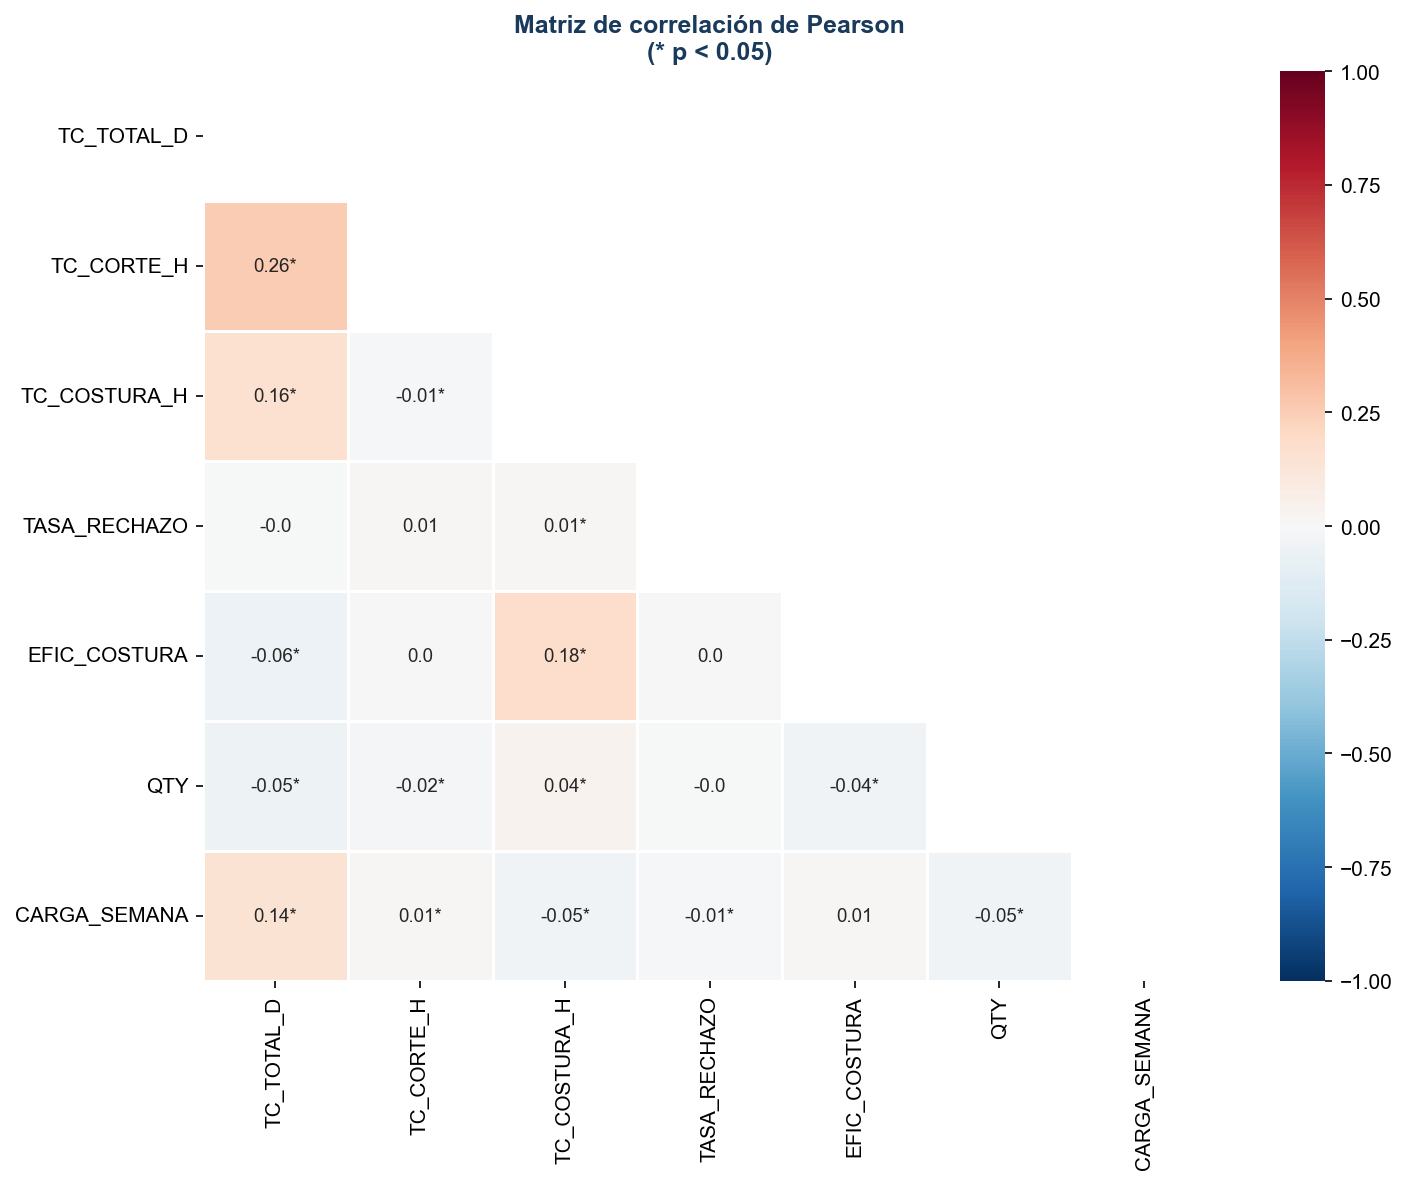

✅ Figura 8 guardada


In [16]:
# ── CELDA 15: FIGURA 8 — Matriz de correlación ────────────────
vars_corr = ["TC_TOTAL_D","TC_CORTE_H","TC_COSTURA_H",
             "TASA_RECHAZO","EFIC_COSTURA","QTY","CARGA_SEMANA"]
corr_matrix = dw[vars_corr].corr()
 
# Calcular p-values para marcar significancia
from scipy.stats import pearsonr
p_matrix = pd.DataFrame(np.ones_like(corr_matrix),
                         index=corr_matrix.index, columns=corr_matrix.columns)
for i in vars_corr:
    for j in vars_corr:
        if i != j:
            mask = dw[[i,j]].dropna()
            if len(mask) > 3:
                _, p = pearsonr(mask[i], mask[j])
                p_matrix.loc[i, j] = p
 
labels = corr_matrix.round(2).astype(str)
labels[p_matrix < 0.05] = labels[p_matrix < 0.05] + "*"
 
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=labels, fmt="", mask=mask,
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Matriz de correlación de Pearson\n(* p < 0.05)",
             fontsize=12, fontweight="bold", color="#1a3a5c")
plt.tight_layout()
plt.savefig("figura08_correlacion.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("✅ Figura 8 guardada")

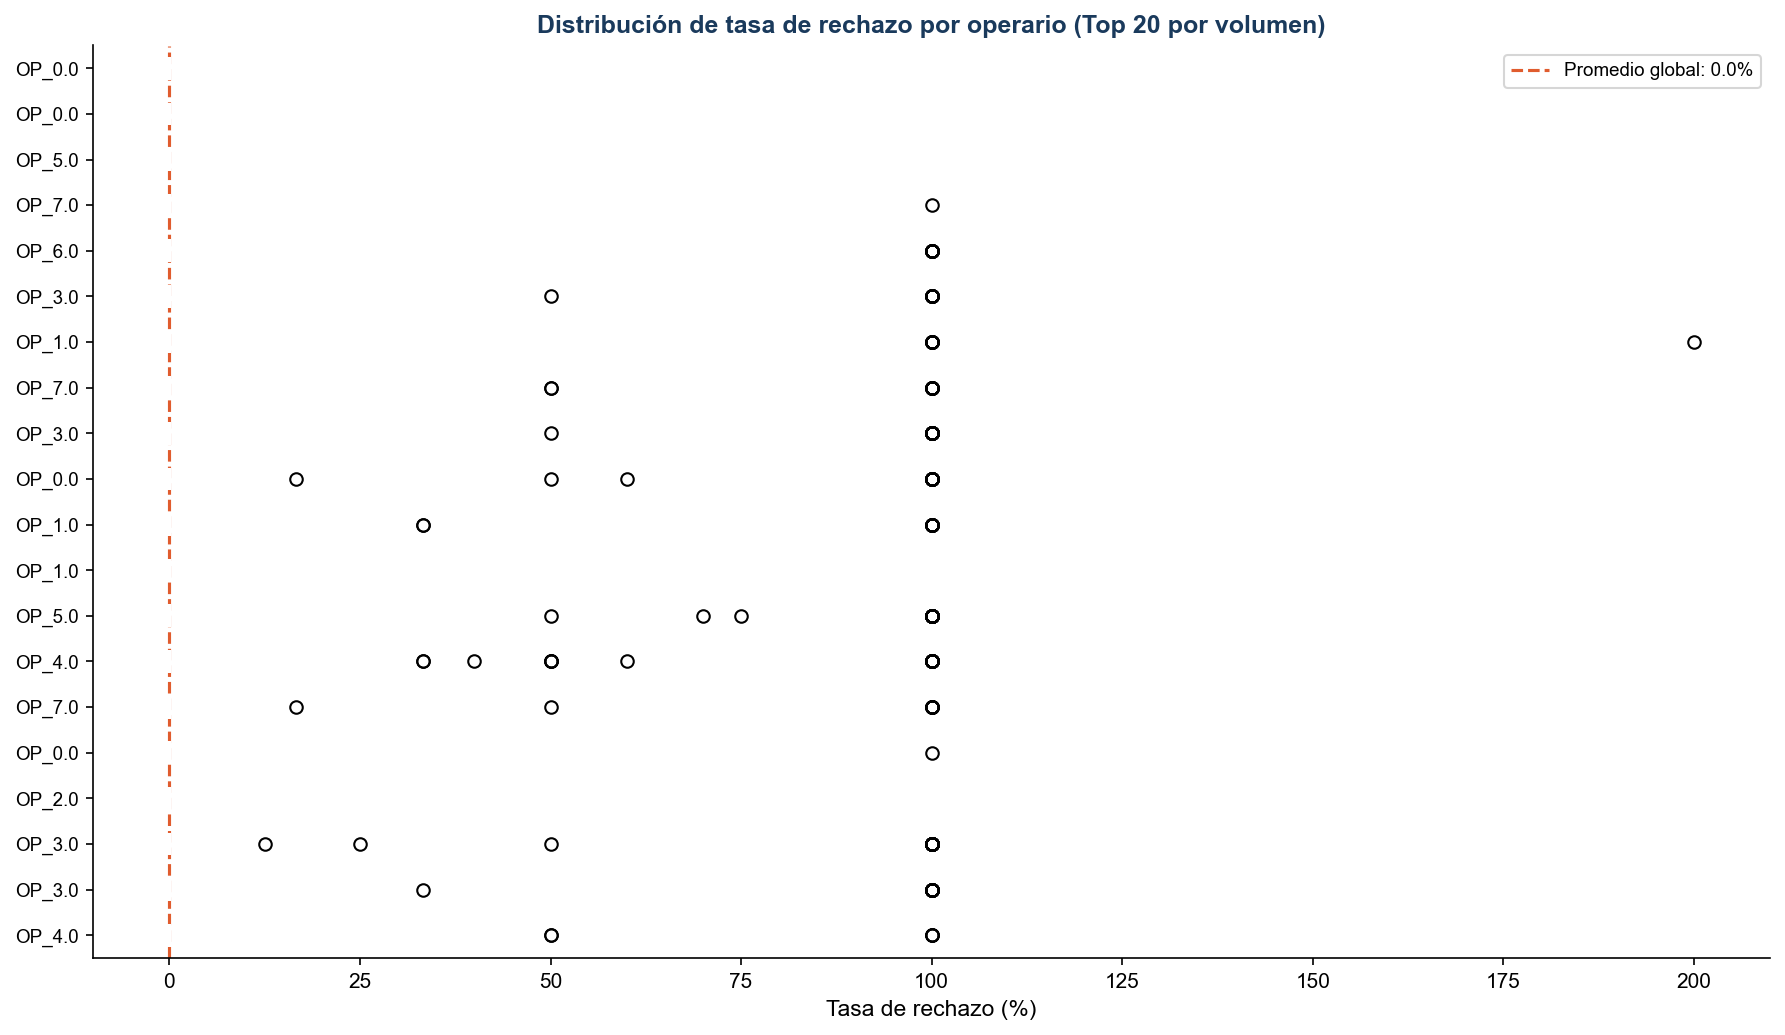

✅ Figura 9 guardada


In [17]:
# ── CELDA 16: FIGURA 9 — Tasa rechazo por operario (Top 20) ───
if "OPERARIO_COSTURA" in dw.columns:
    top_ops = (dw.groupby("OPERARIO_COSTURA")
                 .filter(lambda g: len(g) >= 5)   # mínimo 5 WO para representatividad
                 .groupby("OPERARIO_COSTURA")["TASA_RECHAZO"]
                 .median()
                 .nlargest(20)
                 .index)
 
    data_op = [dw[dw["OPERARIO_COSTURA"]==op]["TASA_RECHAZO"].dropna()
               for op in top_ops]
    medians_op = [s.median() for s in data_op]
    # Anonimizar IDs
    labels_op = [f"OP_{str(op)[-3:]}" for op in top_ops]
    order_idx  = np.argsort(medians_op)[::-1]
 
    fig, ax = plt.subplots(figsize=(12, 7))
    bp = ax.boxplot([data_op[i] for i in order_idx],
                    vert=False, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(COLOR_CORP)
        patch.set_alpha(0.75)
    ax.set_yticklabels([labels_op[i] for i in order_idx], fontsize=9)
    prom_global = dw["TASA_RECHAZO"].median()
    ax.axvline(prom_global, color="#E05C2E", linestyle="--",
               linewidth=1.5, label=f"Promedio global: {prom_global:.1f}%")
    ax.set_xlabel("Tasa de rechazo (%)")
    ax.set_title("Distribución de tasa de rechazo por operario (Top 20 por volumen)",
                 fontsize=12, fontweight="bold", color="#1a3a5c")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("figura09_rechazo_operario.png", dpi=150, bbox_inches="tight",
                facecolor="white")
    plt.show()
    print("✅ Figura 9 guardada")

Tiempo Ciclo Total (días): Q1=1.96, Q3=5.90, Límite=11.81, Outliers=416 (1.0%)
Cantidad Defectos: Q1=0.00, Q3=0.00, Límite=0.00, Outliers=848 (1.9%)
Tasa Rechazo (%): Q1=0.00, Q3=0.00, Límite=0.00, Outliers=844 (2.0%)
Eficiencia Costura (%): Q1=8.22, Q3=296.37, Límite=728.59, Outliers=0 (0.0%)


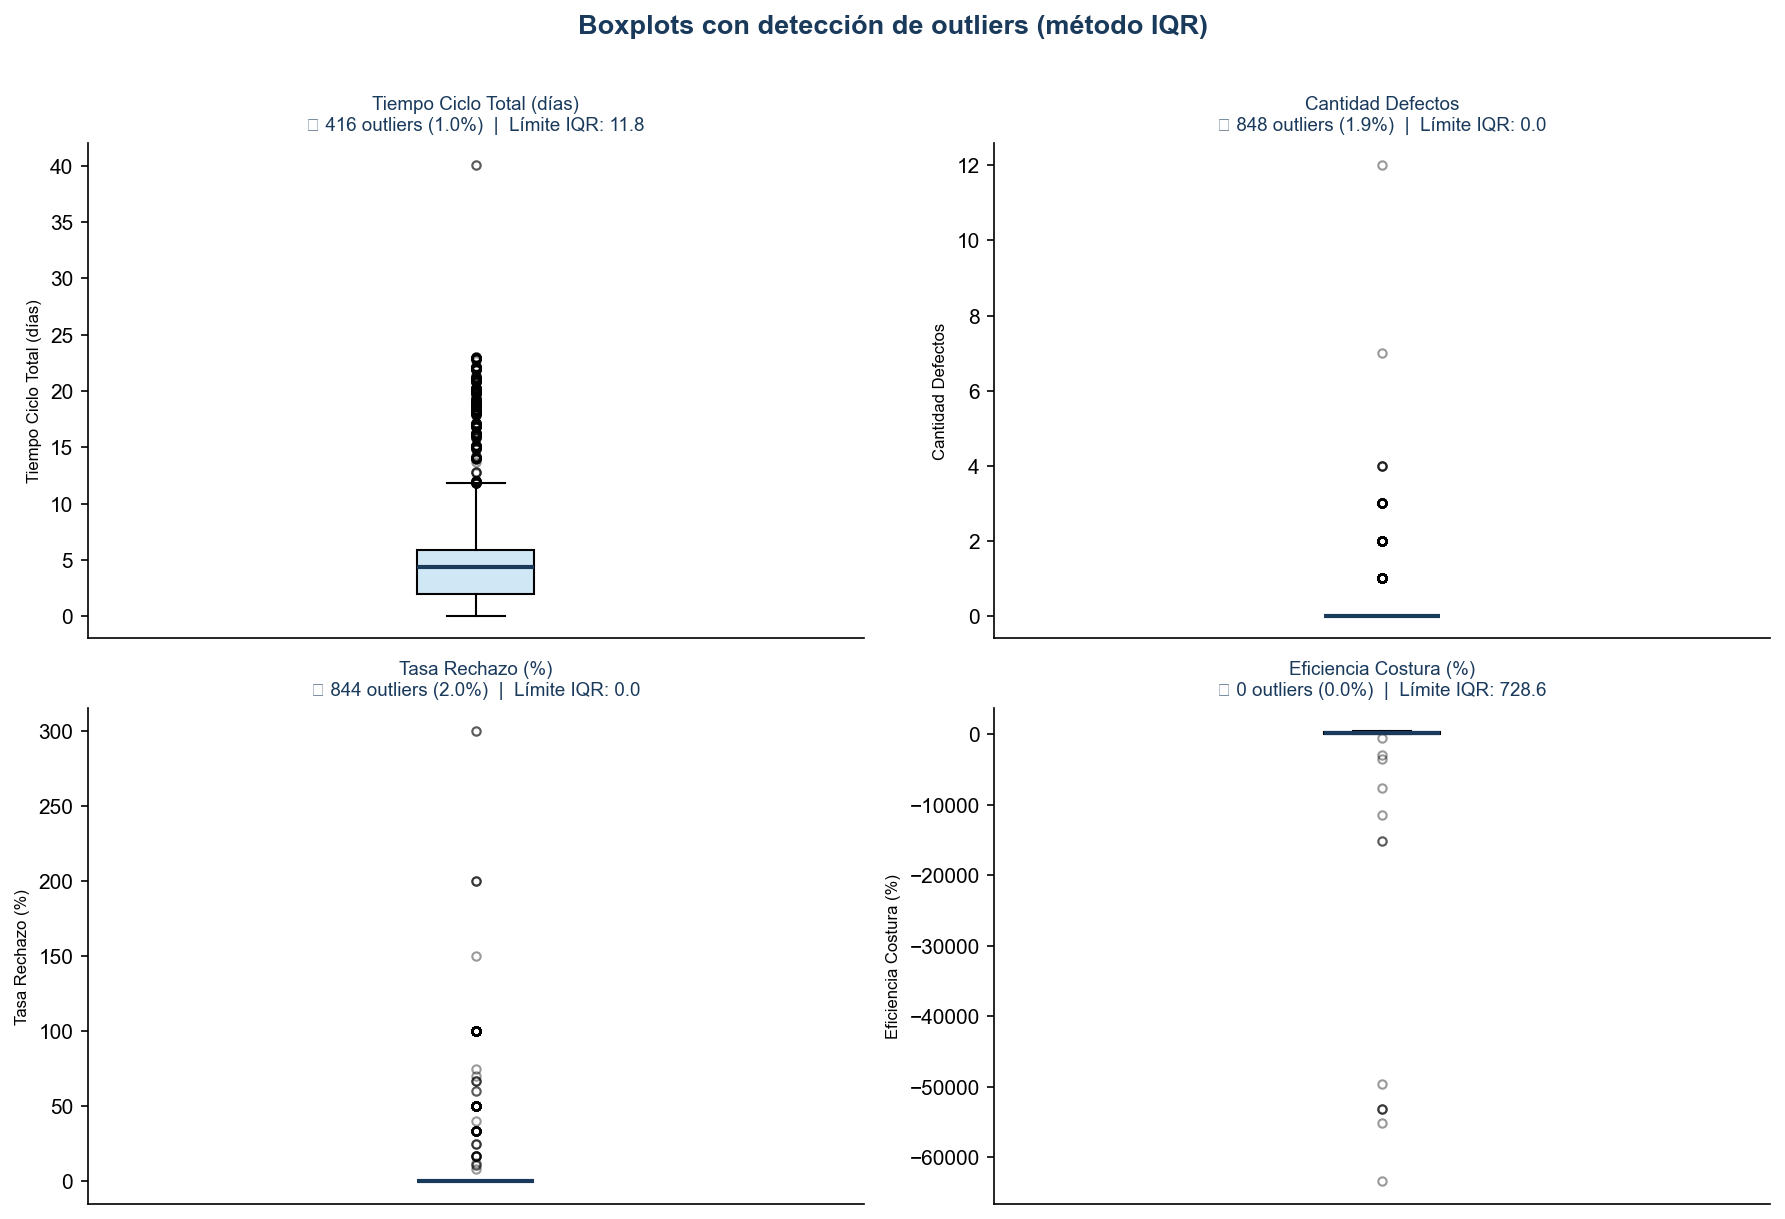


✅ Figura 11 guardada — copia los valores en la Tabla 11 del Word


In [18]:
# ── CELDA 17: FIGURA 11 — Boxplots outliers ───────────────────
vars_box = ["TC_TOTAL_D","QTY_RECH_TOT","TASA_RECHAZO","EFIC_COSTURA"]
labels_box = ["Tiempo Ciclo Total (días)","Cantidad Defectos",
              "Tasa Rechazo (%)","Eficiencia Costura (%)"]
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
 
for ax, col, label in zip(axes, vars_box, labels_box):
    data = dw[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR    = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    n_out   = (data > lim_sup).sum()
    pct_out = n_out / len(data) * 100
 
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    flierprops=dict(marker="o", color=COLOR_CORP,
                                    alpha=0.4, markersize=4))
    bp["boxes"][0].set_facecolor("#D0E8F5")
    bp["medians"][0].set_color("#1a3a5c")
    bp["medians"][0].set_linewidth(2)
 
    ax.set_title(f"{label}\n⚠ {n_out} outliers ({pct_out:.1f}%)  |  "
                 f"Límite IQR: {lim_sup:.1f}",
                 fontsize=9, color="#1a3a5c")
    ax.set_ylabel(label, fontsize=8)
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
 
    print(f"{label}: Q1={Q1:.2f}, Q3={Q3:.2f}, Límite={lim_sup:.2f}, "
          f"Outliers={n_out} ({pct_out:.1f}%)")
 
plt.suptitle("Boxplots con detección de outliers (método IQR)",
             fontsize=13, fontweight="bold", color="#1a3a5c", y=1.01)
plt.tight_layout()
plt.savefig("figura11_boxplots.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("\n✅ Figura 11 guardada — copia los valores en la Tabla 11 del Word")

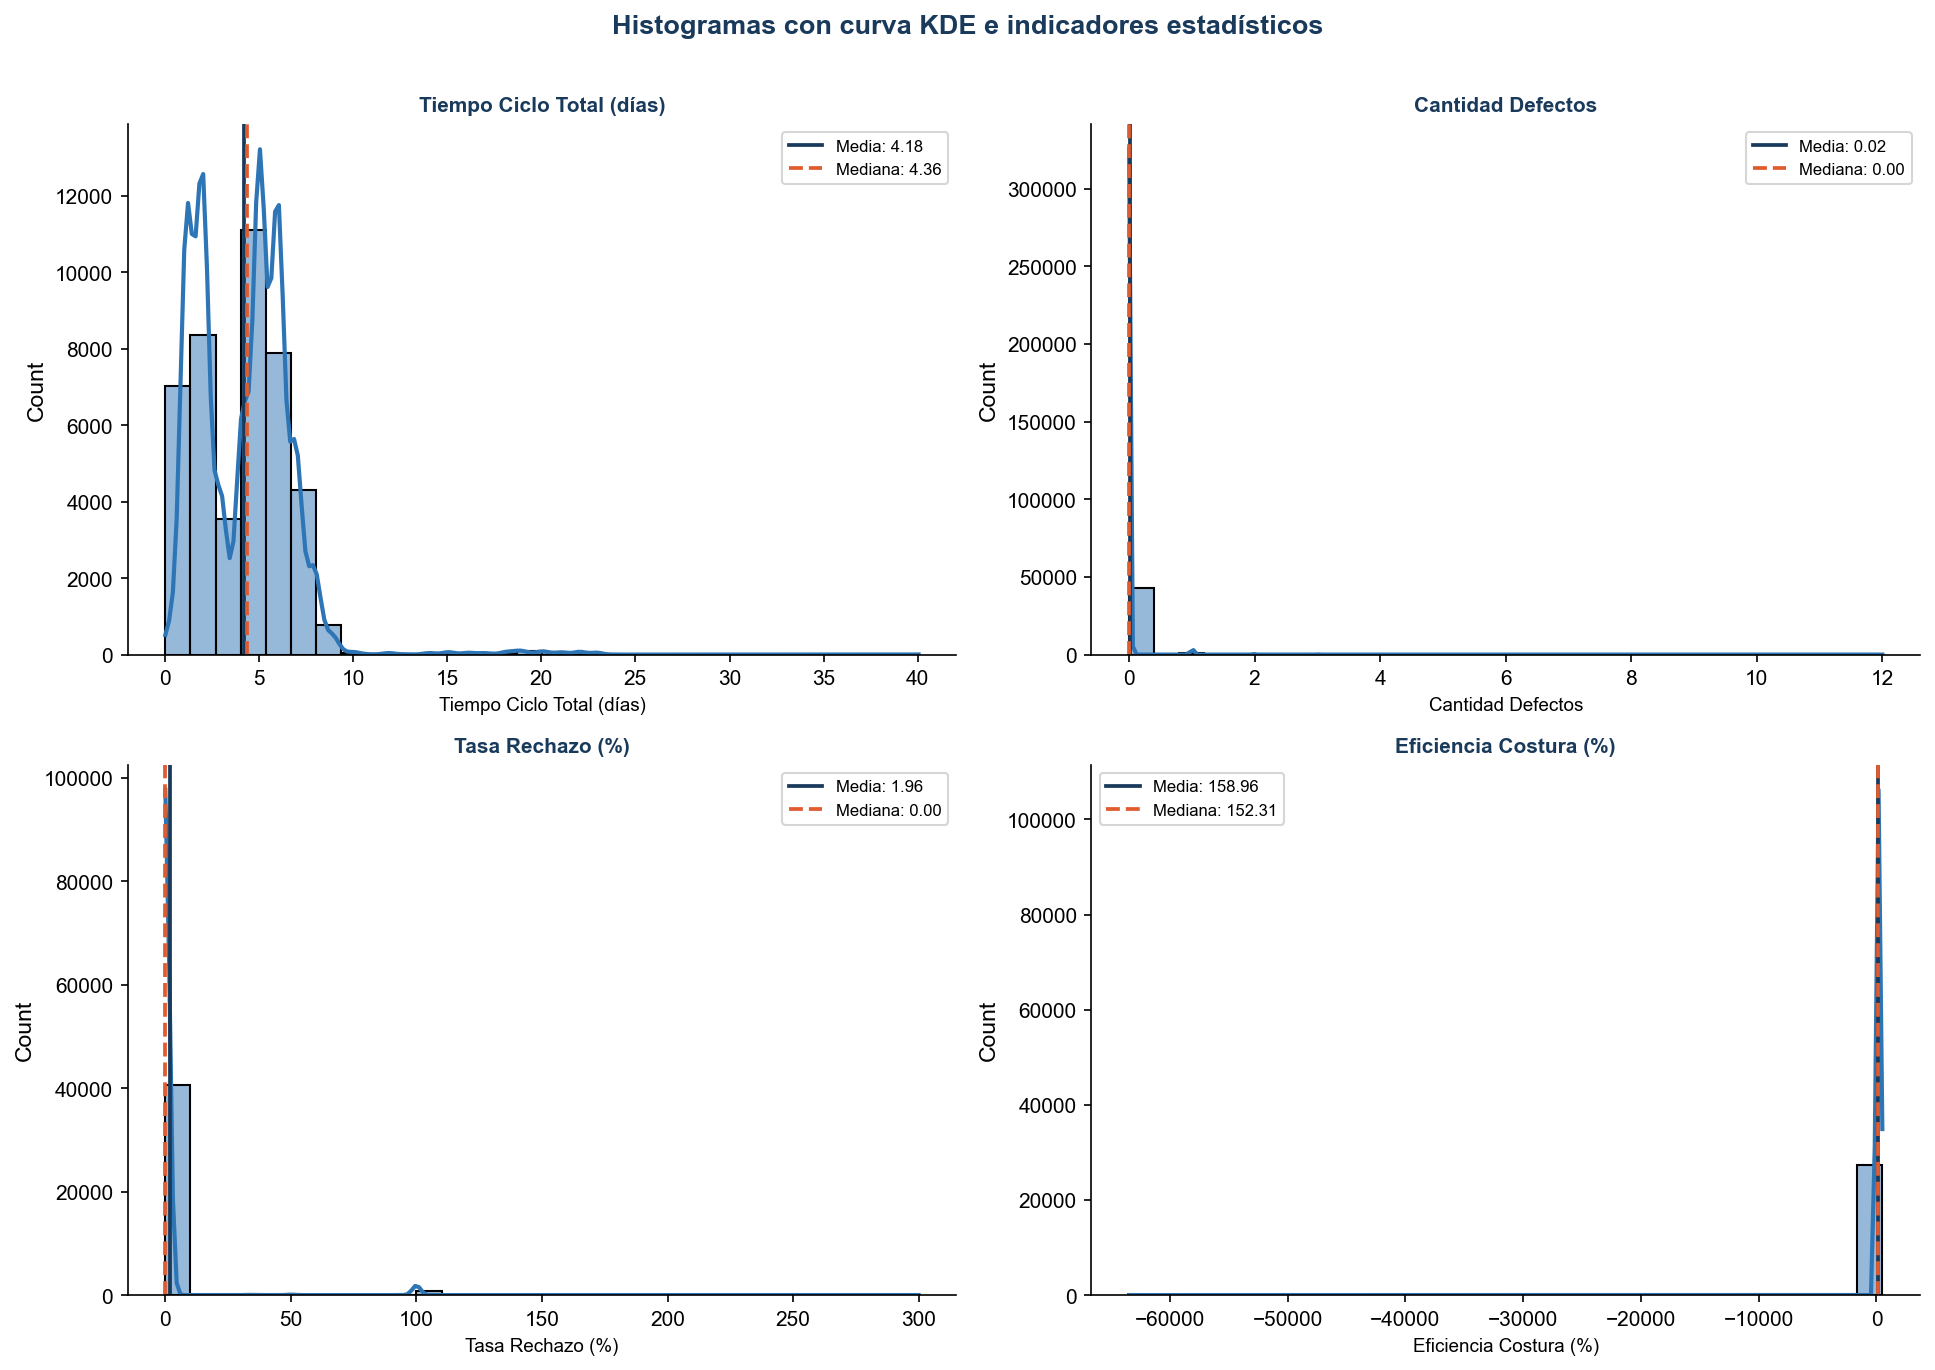

✅ Figura 12 guardada


In [19]:
# ── CELDA 18: FIGURA 12 — Histogramas + KDE ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
 
for ax, col, label in zip(axes, vars_box, labels_box):
    data = dw[col].dropna()
    sns.histplot(data, kde=True, ax=ax, color=COLOR_CORP,
                 alpha=0.5, bins=30, line_kws={"linewidth":2})
    ax.axvline(data.mean(),   color="#1a3a5c", ls="-",  lw=1.8,
               label=f"Media: {data.mean():.2f}")
    ax.axvline(data.median(), color="#E05C2E", ls="--", lw=1.8,
               label=f"Mediana: {data.median():.2f}")
    ax.set_title(label, fontsize=10, fontweight="bold", color="#1a3a5c")
    ax.set_xlabel(label, fontsize=9)
    ax.legend(fontsize=8)
 
plt.suptitle("Histogramas con curva KDE e indicadores estadísticos",
             fontsize=13, fontweight="bold", color="#1a3a5c", y=1.01)
plt.tight_layout()
plt.savefig("figura12_histogramas.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("✅ Figura 12 guardada")


Tiempo Ciclo Total (días): W=0.8548, p=0.0000
Cantidad Defectos: W=0.1150, p=0.0000
Tasa Rechazo (%): W=0.1052, p=0.0000
Eficiencia Costura (%): W=0.0397, p=0.0000


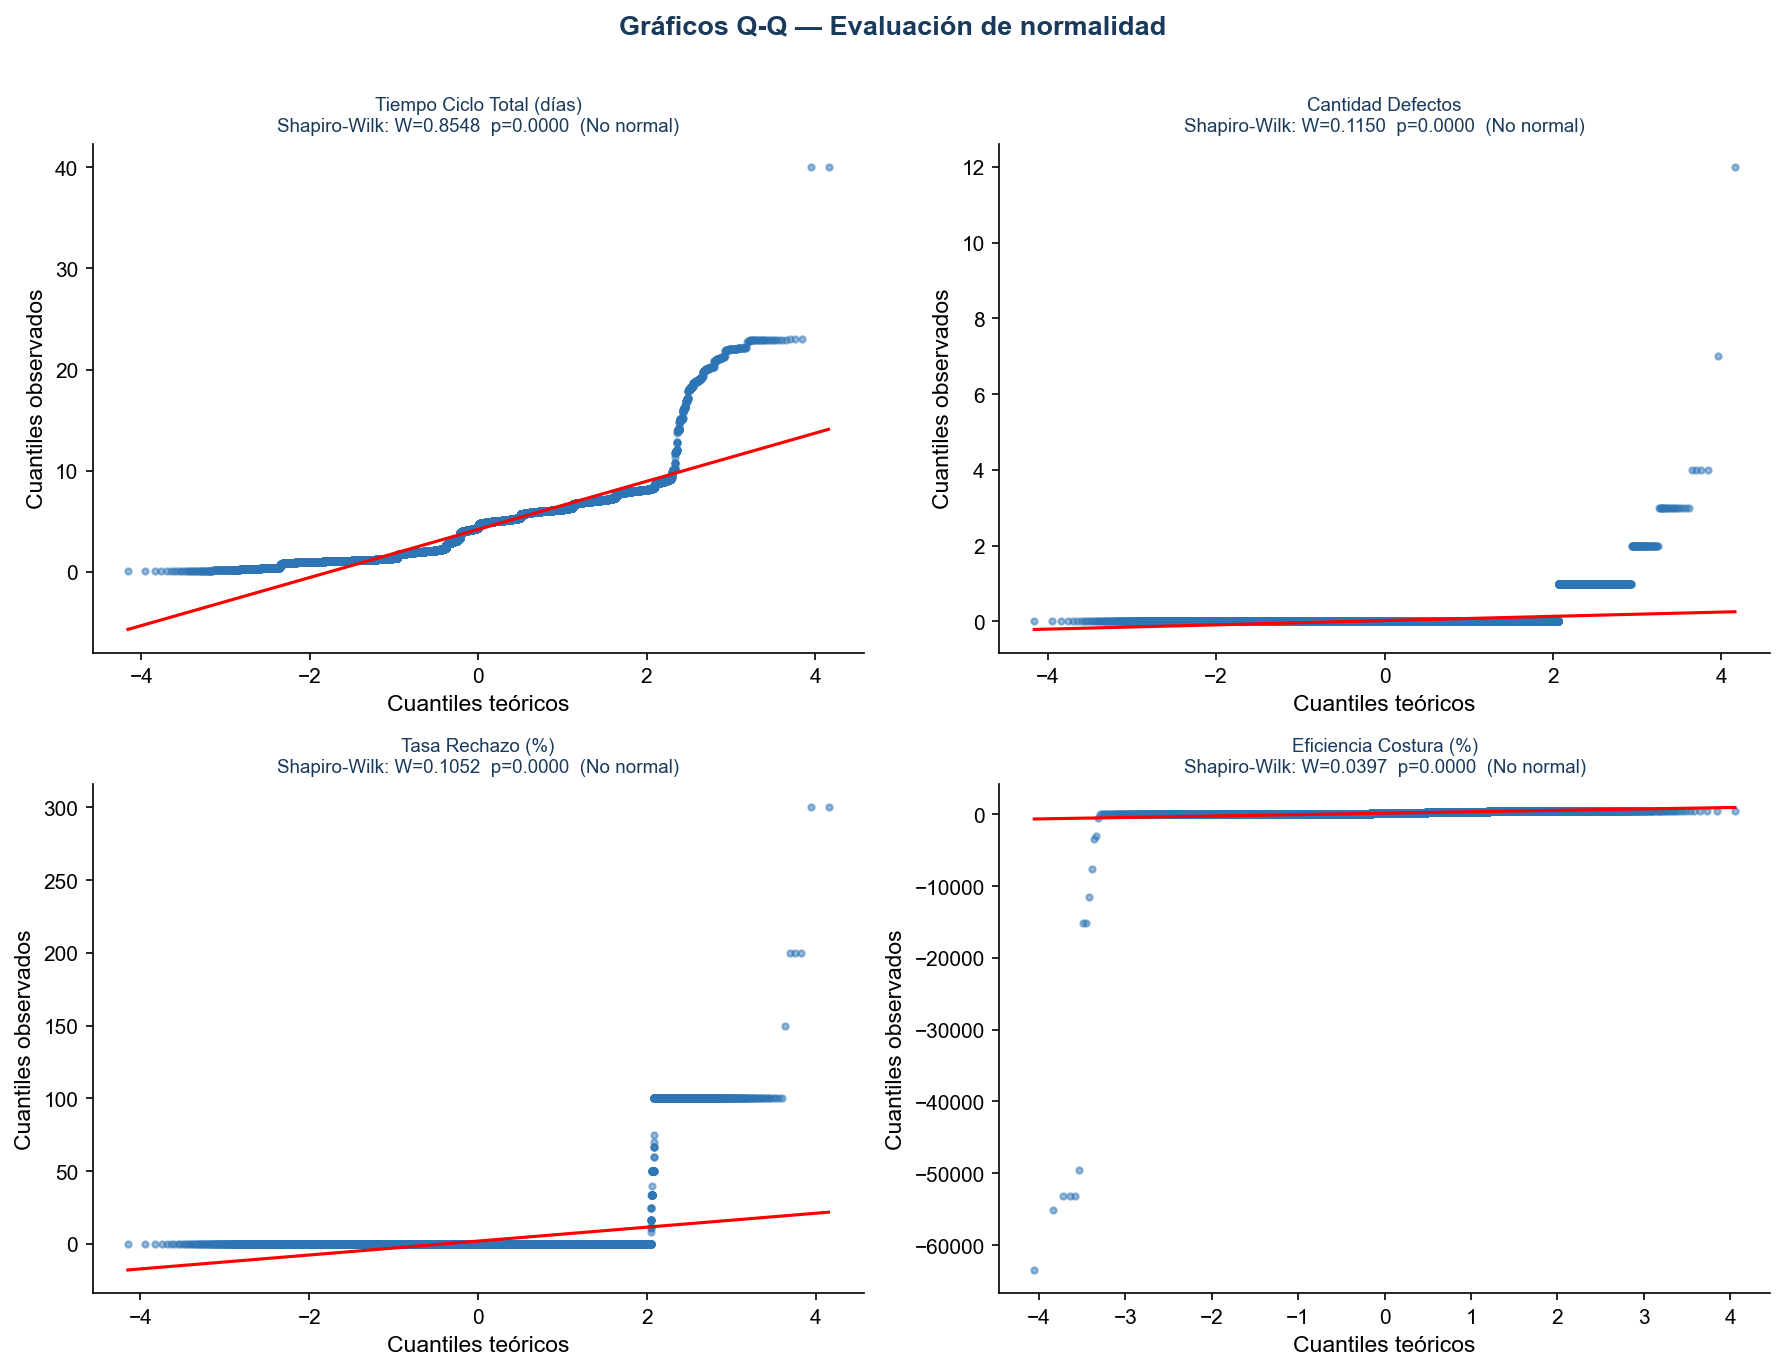


✅ Figura 13 guardada — copia los valores en la Tabla 12 del Word


In [20]:
# ── CELDA 19: FIGURA 13 — Q-Q plots (normalidad) ─────────────
from scipy import stats as st
 
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
 
for ax, col, label in zip(axes, vars_box, labels_box):
    data = dw[col].dropna()
    (osm, osr), (slope, intercept, r) = st.probplot(data, dist="norm")
    ax.plot(osm, osr, "o", color=COLOR_CORP, alpha=0.5, markersize=3)
    ax.plot(osm, slope*np.array(osm)+intercept, "r-", lw=1.5)
    W, p = st.shapiro(data.sample(min(5000, len(data)), random_state=42))
    ax.set_title(f"{label}\nShapiro-Wilk: W={W:.4f}  p={p:.4f}  "
                 f"({'Normal' if p>0.05 else 'No normal'})",
                 fontsize=9, color="#1a3a5c")
    ax.set_xlabel("Cuantiles teóricos")
    ax.set_ylabel("Cuantiles observados")
    print(f"{label}: W={W:.4f}, p={p:.4f}")
 
plt.suptitle("Gráficos Q-Q — Evaluación de normalidad",
             fontsize=13, fontweight="bold", color="#1a3a5c", y=1.01)
plt.tight_layout()
plt.savefig("figura13_qq_plots.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("\n✅ Figura 13 guardada — copia los valores en la Tabla 12 del Word")

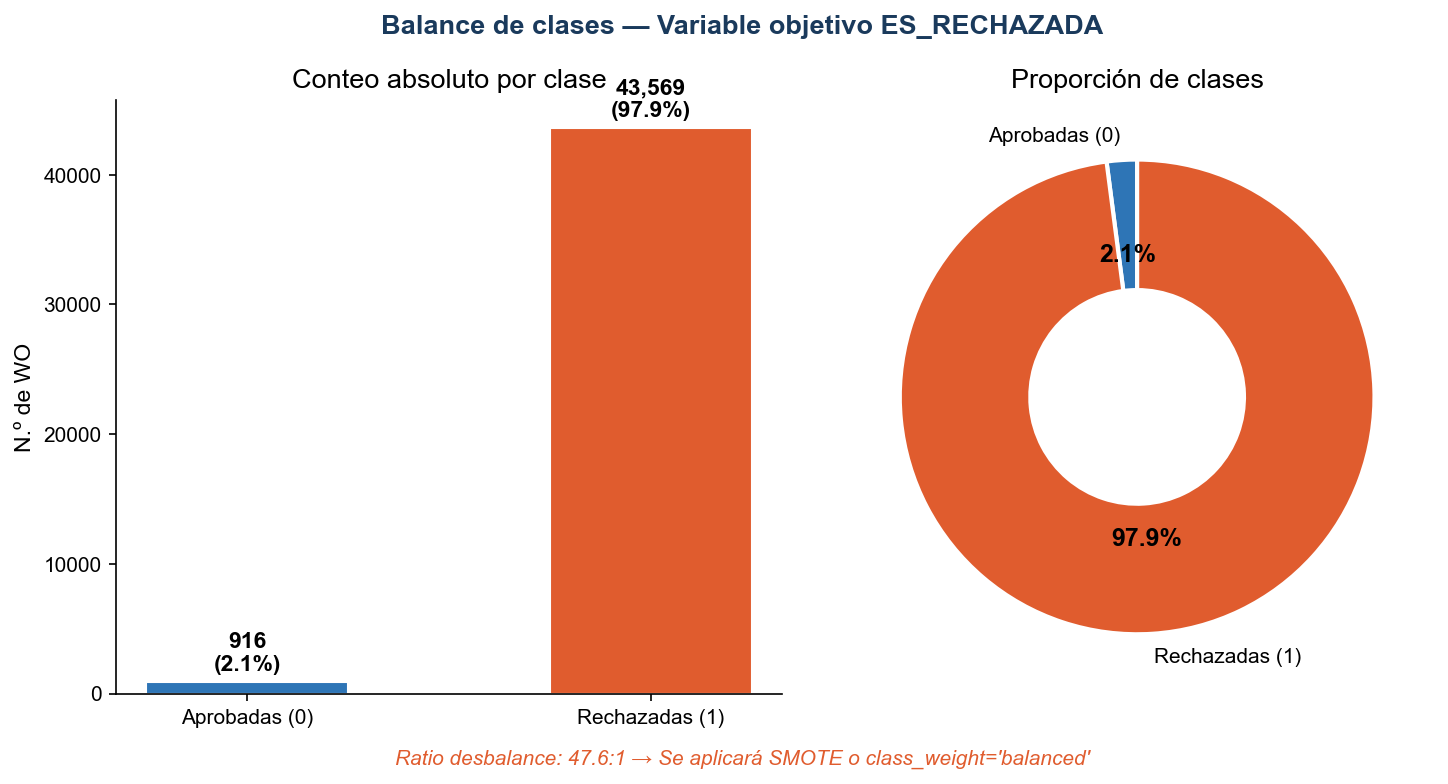

✅ Figura 14 guardada | Ratio desbalance: 47.6:1 → Se aplicará SMOTE o class_weight='balanced'


In [21]:
# ── CELDA 20: FIGURA 14 — Balance de clases ───────────────────
clases = dw["ES_RECHAZADA"].value_counts().sort_index()
labels_c = ["Aprobadas (0)", "Rechazadas (1)"]
colors_c  = ["#2E75B6", "#E05C2E"]
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.bar(labels_c, clases.values, color=colors_c, edgecolor="white", width=0.5)
for i, v in enumerate(clases.values):
    pct = v/clases.sum()*100
    ax1.text(i, v + clases.max()*0.02, f"{v:,}\n({pct:.1f}%)",
             ha="center", fontsize=11, fontweight="bold")
ax1.set_title("Conteo absoluto por clase")
ax1.set_ylabel("N.º de WO")
 
wedges, texts, autotexts = ax2.pie(
    clases.values, labels=labels_c, colors=colors_c,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight("bold")
ax2.set_title("Proporción de clases")
 
ratio = clases.max() / clases.min()
nota  = f"Ratio desbalance: {ratio:.1f}:1"
if ratio > 4:
    nota += " → Se aplicará SMOTE o class_weight='balanced'"
fig.text(0.5, -0.02, nota, ha="center", fontsize=10,
         color="#E05C2E", style="italic")
 
plt.suptitle("Balance de clases — Variable objetivo ES_RECHAZADA",
             fontsize=13, fontweight="bold", color="#1a3a5c")
plt.tight_layout()
plt.savefig("figura14_balance_clases.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print(f"✅ Figura 14 guardada | {nota}")

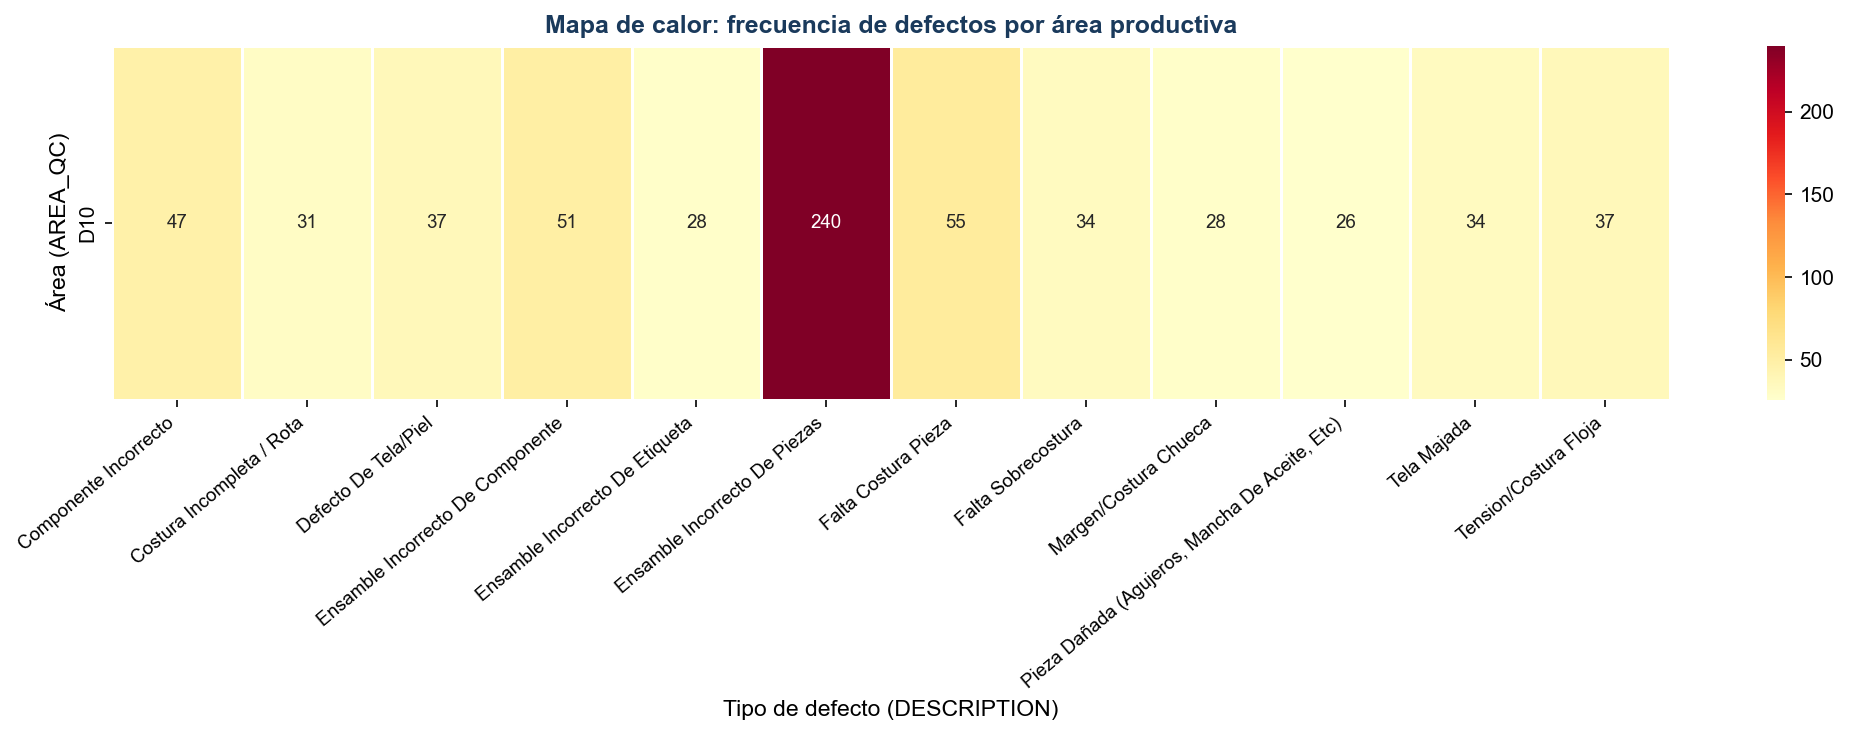

✅ Figura 15 guardada (sin 'Sin Defectos')


In [22]:
# ── CELDA 21: FIGURA 15 — Mapa de calor defectos × área ───────

if "AREA_QC" in df_qc_enriq.columns and "DESCRIPTION" in df_qc_enriq.columns:

    # 🔹 LIMPIEZA Y FILTRO
    col = df_qc_enriq["DESCRIPTION"].str.strip().str.lower()

    df_filtrado = df_qc_enriq[
        col.notna() &
        (col != "") &
        (~col.eq("sin defectos"))
    ].copy()

    # 🔹 Construcción del pivot
    pivot = (df_filtrado
             .groupby(["AREA_QC", "DESCRIPTION"])["ES_RECHAZADA"]
             .count()
             .unstack(fill_value=0))

    # 🔹 Mantener top 12 defectos (ya filtrado)
    top12 = df_filtrado["DESCRIPTION"].value_counts().head(12).index
    pivot  = pivot[pivot.columns.intersection(top12)]

    # 🔹 Gráfica
    fig, ax = plt.subplots(figsize=(14, 5))

    sns.heatmap(
        pivot,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": 9}
    )

    ax.set_title(
        "Mapa de calor: frecuencia de defectos por área productiva",
        fontsize=12,
        fontweight="bold",
        color="#1a3a5c"
    )

    ax.set_xlabel("Tipo de defecto (DESCRIPTION)")
    ax.set_ylabel("Área (AREA_QC)")

    plt.xticks(rotation=40, ha="right", fontsize=9)

    plt.tight_layout()

    plt.savefig(
        "figura15_heatmap_defectos.png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

    print("✅ Figura 15 guardada (sin 'Sin Defectos')")

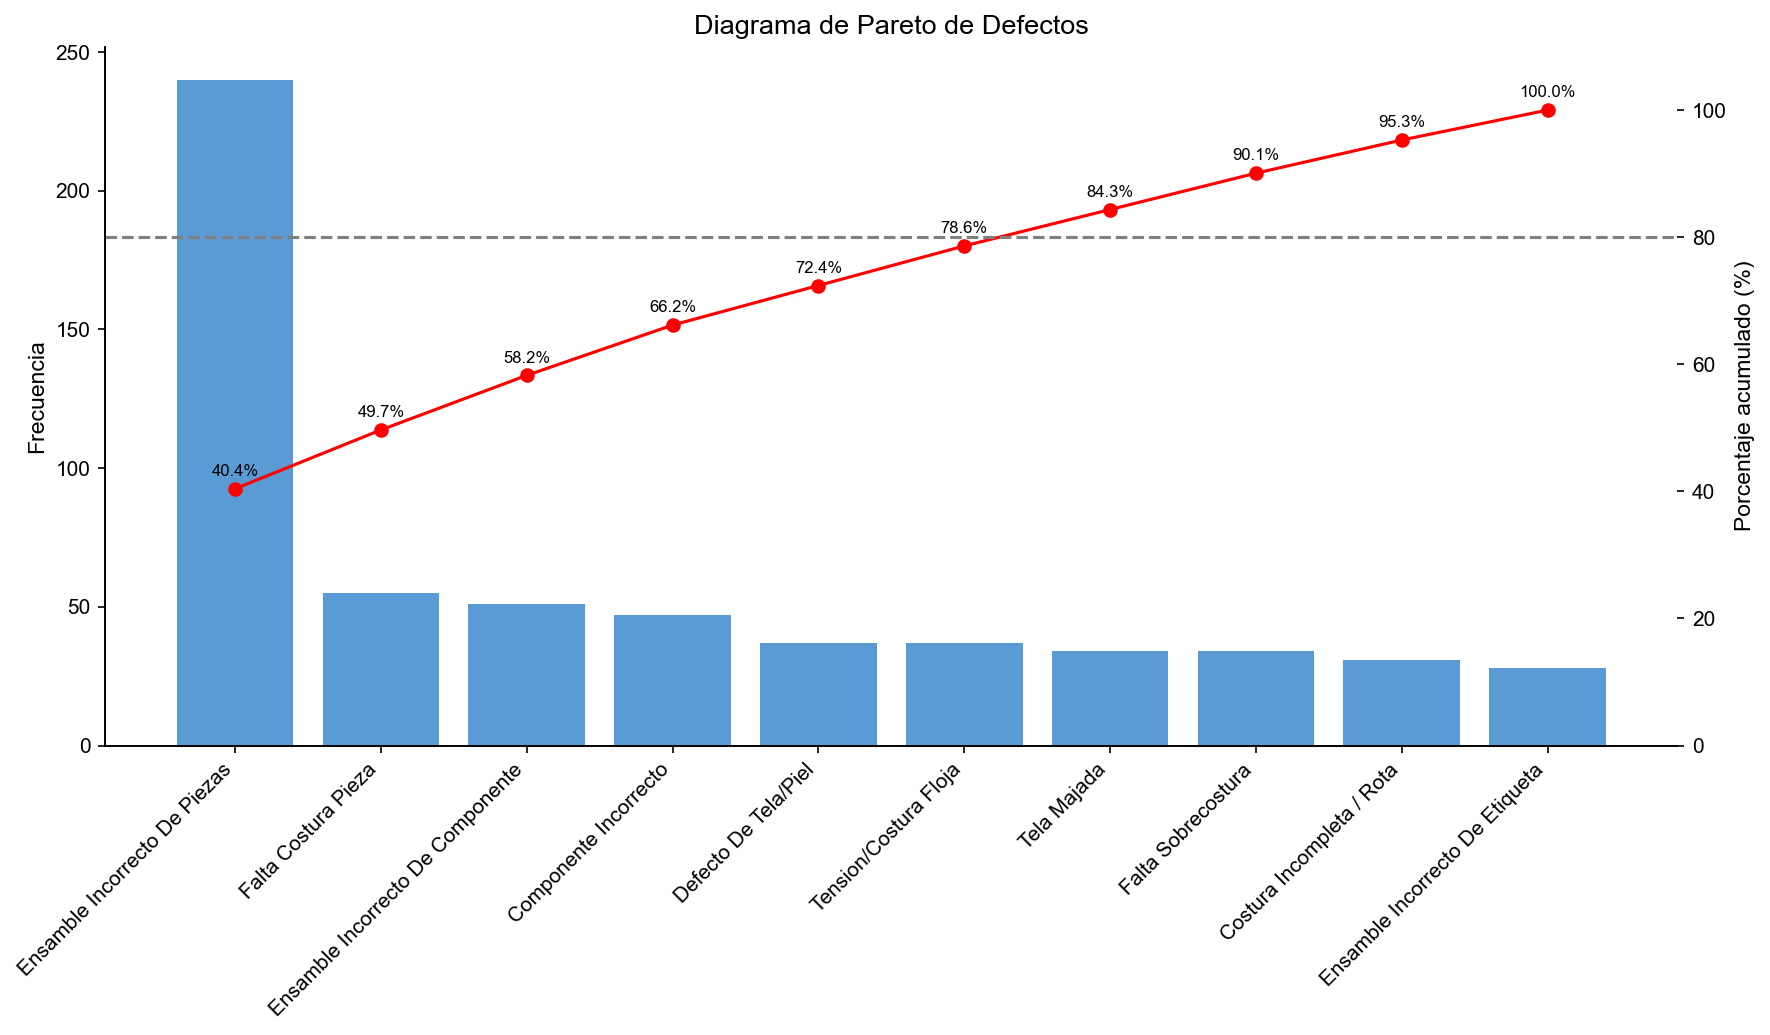

✅ Figura 16 guardada


In [23]:
# ── CELDA 22: FIGURA 16 — Diagrama de Pareto ─────────────────
fig, ax1 = plt.subplots(figsize=(12, 7))

# Normalizar columna
col = df_qc_enriq["DESCRIPTION"].str.strip().str.lower()

# Filtrar "Sin Defectos" y vacíos
df_filtrado = df_qc_enriq[
    col.notna() &
    (col != "") &
    (~col.eq("sin defectos"))
]

# Conteo de defectos
defecto_cnt = df_filtrado["DESCRIPTION"].value_counts()

# Top 10
top10 = defecto_cnt.head(10).copy()

# Porcentaje acumulado
acumulado = top10.cumsum() / top10.sum() * 100

# --- BARRAS (frecuencia) ---
ax1.bar(top10.index, top10.values, color=PALETTE[3])
ax1.set_ylabel("Frecuencia")
ax1.set_title("Diagrama de Pareto de Defectos")

# FIX: set_xticklabels() sin haber llamado antes set_xticks() genera
# UserWarning ("FixedFormatter should only be used together with
# FixedLocator") y puede desalinear las etiquetas respecto a las barras
# si matplotlib decide mostrar un subconjunto distinto de ticks (p. ej.
# al redimensionar la figura o exportarla a PNG). Se fijan explícitamente
# las posiciones de los ticks con range(len(top10)) antes de asignar las
# etiquetas, garantizando una correspondencia 1:1 barra↔etiqueta.
ax1.set_xticks(range(len(top10)))
ax1.set_xticklabels(top10.index, rotation=45, ha="right")

# --- LÍNEA (acumulado %) ---
ax2 = ax1.twinx()
ax2.plot(range(len(top10)), acumulado, color="red", marker="o")
ax2.set_ylabel("Porcentaje acumulado (%)")
ax2.set_ylim(0, 110)

# Línea de referencia 80%
ax2.axhline(80, color="gray", linestyle="--")

# Etiquetas de porcentaje
for i, v in enumerate(acumulado):
    ax2.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(
    "figura16_pareto_defectos.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✅ Figura 16 guardada")


In [24]:
# ── CELDA 23: Resumen de archivos generados ───────────────────
import os
archivos = [f for f in os.listdir(".") if f.startswith("figura") or f.endswith(".parquet")]
print("\n" + "="*55)
print("📁 ARCHIVOS GENERADOS")
print("="*55)
for f in sorted(archivos):
    size = os.path.getsize(f) / 1024
    print(f"  {f:<42} {size:>6.1f} KB")
print("\n✅ EDA completado. Inserta las figuras en el documento Word.")


📁 ARCHIVOS GENERADOS
  dataset_QC_eventos.parquet                 1296.0 KB
  dataset_WO_nivel.parquet                   5496.4 KB
  figura04_describe.png                        93.7 KB
  figura05_categoricas.png                    295.1 KB
  figura06_serie_temporal.png                 245.7 KB
  figura07_rechazo_area.png                    60.3 KB
  figura08_correlacion.png                     90.4 KB
  figura09_rechazo_operario.png                81.7 KB
  figura11_boxplots.png                       113.9 KB
  figura12_histogramas.png                    160.6 KB
  figura13_qq_plots.png                       139.2 KB
  figura14_balance_clases.png                  97.0 KB
  figura15_heatmap_defectos.png               131.5 KB
  figura16_pareto_defectos.png                142.1 KB

✅ EDA completado. Inserta las figuras en el documento Word.
